### INTERNET FIREWALL DATA ANALYSIS WITH ANOMALY DETECTION

# Introduction:
 In today’s digital world, cybersecurity plays a crucial role in protecting networks from unauthorized access and malicious activities. Firewalls are one of the primary defense mechanisms used to monitor and control incoming and outgoing network traffic based on predetermined security rules. Analyzing firewall data helps identify patterns of network usage, detect security threats, and enhance organizational security policies. This project focuses on the analysis of internet firewall logs using data science techniques to gain insights into network behavior and potential vulnerabilities.


# Objectives:
To collect and preprocess firewall log data for analysis.


To identify patterns and trends in network traffic.


To detect unusual or suspicious activities using statistical or machine learning techniques.


To visualize the results for better understanding and decision-making.


To provide recommendations to improve firewall efficiency and

# 3.Data Description :  
The firewall dataset contains network traffic logs captured by a firewall device to monitor and control data flow between internal and external networks. Each record represents a network session and includes details such as  source and destination ports, NAT ports, action taken by the firewall (allow/deny), number of bytes and packets transferred, and session duration. This dataset is used to analyze network behavior, detect suspicious activities, and identify anomalies that may indicate cyber attacks or unauthorized access. The original dataset included 65532 rows and 12 columns.


   - Source: https://archive.ics.uci.edu/dataset/542/internet+firewall+data
   - Features: The attribute information is given below.


| Column               | Meaning                          |
| -------------------- | -------------------------------- |
| Source Port          | Sender port                      |
| Destination Port     | Receiver port                    |
| NAT Source Port      | Port after NAT translation       |
| NAT Destination Port | Target port after NAT            |
| Action               | allow / deny / drop/resetboth              |
| Bytes                | Total data transferred           |
| Bytes Sent           | Outbound data                    |
| Bytes Received       | Inbound data                     |
| Packets              | Total packets                    |
| Pkts Sent            | Forward packets                  |
| Pkts Received        | Reverse packets                  |
| Elapsed Time(sec)         | Session duration                 |


#Data collection

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import zscore
from scipy.stats import skew,kurtosis
import warnings
warnings.filterwarnings("ignore")


In [3]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving log2.csv to log2 (1).csv
User uploaded file "log2 (1).csv" with length 2876998 bytes


In [4]:
df=pd.read_csv("//content//log2.csv")
print("✅ Dataset Loaded Successfully!")
df

✅ Dataset Loaded Successfully!


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18
...,...,...,...,...,...,...,...,...,...,...,...,...
65527,63691,80,13237,80,allow,314,192,122,6,15,4,2
65528,50964,80,13485,80,allow,4680740,67312,4613428,4675,77,985,3690
65529,54871,445,0,0,drop,70,70,0,1,0,1,0
65530,54870,445,0,0,drop,70,70,0,1,0,1,0


In [4]:
# check the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Source Port           65532 non-null  int64 
 1   Destination Port      65532 non-null  int64 
 2   NAT Source Port       65532 non-null  int64 
 3   NAT Destination Port  65532 non-null  int64 
 4   Action                65532 non-null  object
 5   Bytes                 65532 non-null  int64 
 6   Bytes Sent            65532 non-null  int64 
 7   Bytes Received        65532 non-null  int64 
 8   Packets               65532 non-null  int64 
 9   Elapsed Time (sec)    65532 non-null  int64 
 10  pkts_sent             65532 non-null  int64 
 11  pkts_received         65532 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 6.0+ MB


In [5]:
print(f"Shape of the data: {df.shape}")

Shape of the data: (65532, 12)


#Exploratory Data Analysis

In [6]:
# Data Preprocessing - Data Cleaning:

In [5]:
# Show summary statistics for numerical columns
display(df.describe())

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,65532.000000,65532.000000,65532.000000,65532.000000,6.553200e+04,6.553200e+04,6.553200e+04,6.553200e+04,65532.000000,65532.000000,65532.000000
mean,49391.969343,10577.385812,19282.972761,2671.049930,9.712395e+04,2.238580e+04,7.473815e+04,1.028660e+02,65.833577,41.399530,61.466505
std,15255.712537,18466.027039,21970.689669,9739.162278,5.618439e+06,3.828139e+06,2.463208e+06,5.133002e+03,302.461762,3218.871288,2223.332271
min,0.000000,0.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
25%,49183.000000,80.000000,0.000000,0.000000,6.600000e+01,6.600000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
50%,53776.500000,445.000000,8820.500000,53.000000,1.680000e+02,9.000000e+01,7.900000e+01,2.000000e+00,15.000000,1.000000,1.000000
75%,58638.000000,15000.000000,38366.250000,443.000000,7.522500e+02,2.100000e+02,4.490000e+02,6.000000e+00,30.000000,3.000000,2.000000
max,65534.000000,65535.000000,65535.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000


In [8]:
# Check for missing values
display(df.isnull().sum())

,0
Source Port,0
Destination Port,0
NAT Source Port,0
NAT Destination Port,0
Action,0
Bytes,0
Bytes Sent,0
Bytes Received,0
Packets,0
Elapsed Time (sec),0


In [6]:
# Checking for duplicates
df.duplicated().sum()


np.int64(8362)

8362 duplicate rows found in df.

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
print("\nTarget column value counts:")
print(df['Action'].value_counts())


Target column value counts:
Action
allow         37439
drop          11635
deny           8042
reset-both       54
Name: count, dtype: int64


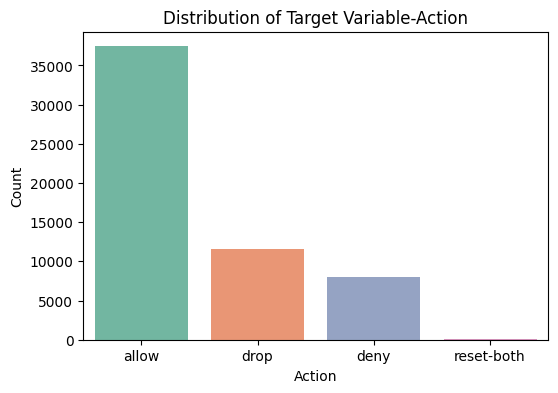

In [12]:
# Visualize the distribution of the target variable 'Action' column
plt.figure(figsize=(6,4))
sns.countplot(x='Action', data=df, palette='Set2')
plt.title("Distribution of Target Variable-Action")
plt.xlabel('Action')
plt.ylabel('Count')
plt.show()

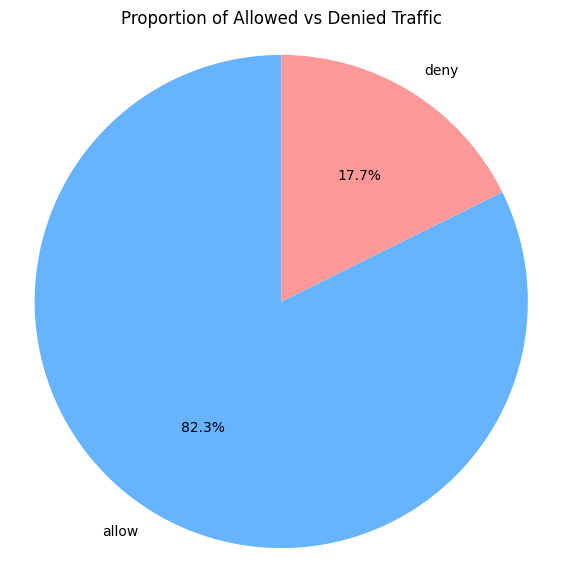

In [13]:
# Pie Chart for Allowed vs Denied Traffic

import matplotlib.pyplot as plt
import pandas as pd

# Filter for 'allow' and 'deny' actions
allowed_denied_traffic = df[df['Action'].isin(['allow', 'deny'])]

# Get value counts
action_counts = allowed_denied_traffic['Action'].value_counts()

# Create a pie chart
plt.figure(figsize=(7, 7))
plt.pie(action_counts, labels=action_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Proportion of Allowed vs Denied Traffic')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

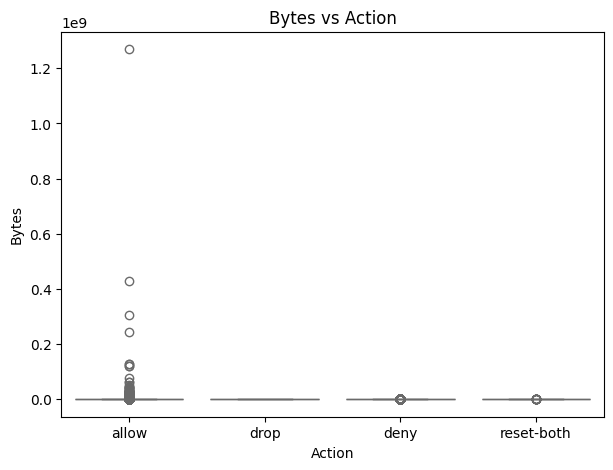

In [14]:
# Bytes vs Action
plt.figure(figsize=(7,5))
sns.boxplot(x='Action', y='Bytes', data=df, palette='Set3')
plt.title("Bytes vs Action")
plt.show()


In [15]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", list(categorical_cols))


Categorical columns: ['Action']


Numeric columns: ['Source Port', 'Destination Port', 'NAT Source Port', 'NAT Destination Port', 'Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent', 'pkts_received']


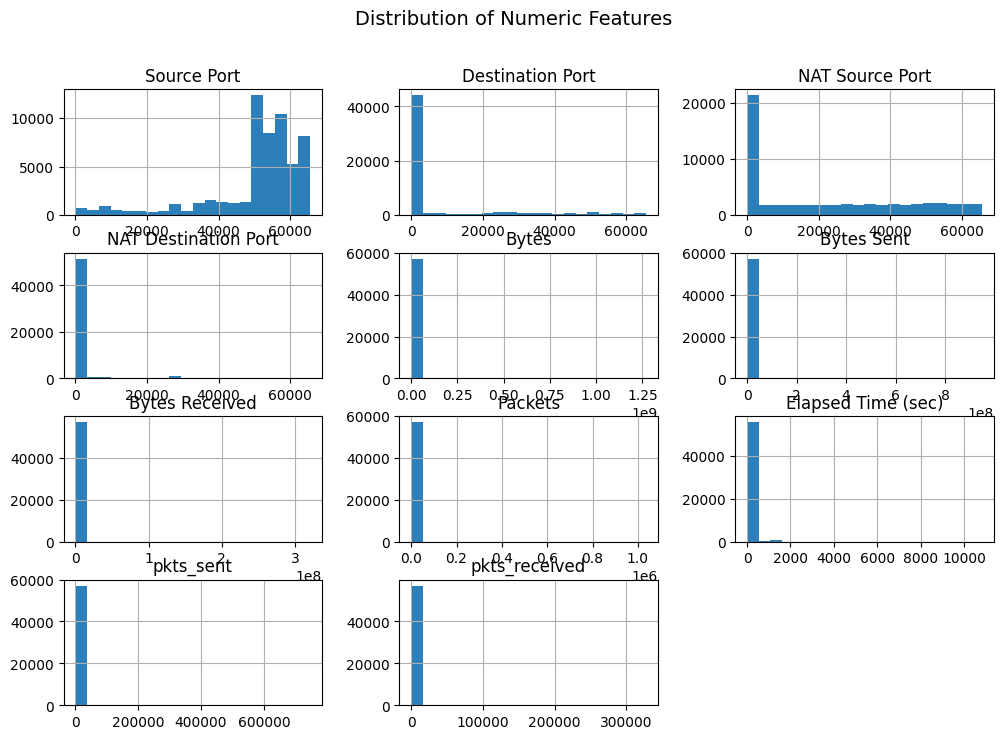

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:", list(numeric_cols))

df[numeric_cols].hist(figsize=(12, 8), bins=20, color='#2c7fb8')
plt.suptitle("Distribution of Numeric Features", fontsize=14)
plt.show()



## Analyze Numerical Feature Distributions with Skewness and Kurtosis

For each numerical column in the DataFrame, generate a histogram and a box plot to visualize its distribution, spread, and identify outliers. Additionally, calculate and print the skewness and kurtosis for each numerical feature to quantify the shape and tail-heaviness of its distribution.


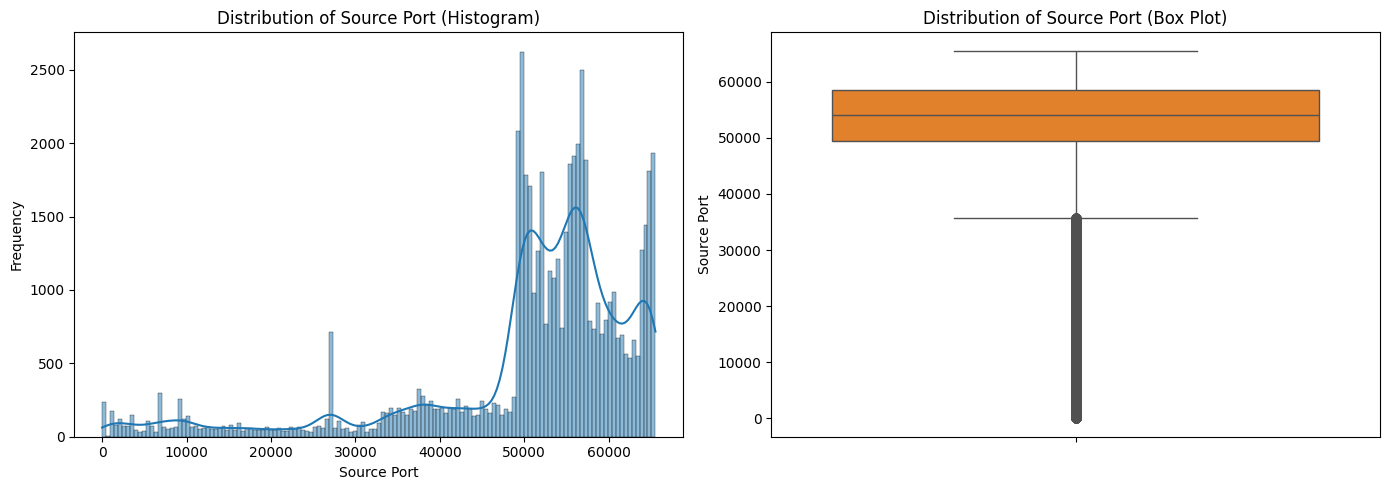

Skewness for Source Port: -1.85
Kurtosis for Source Port: 3.26
----------------------------------------------------


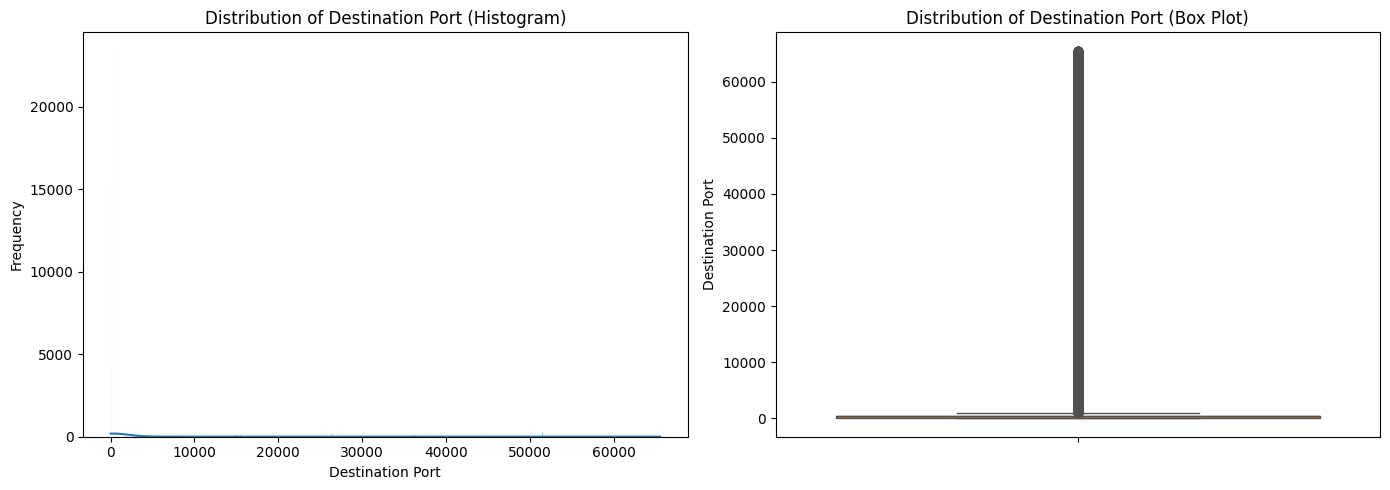

Skewness for Destination Port: 2.04
Kurtosis for Destination Port: 2.85
----------------------------------------------------


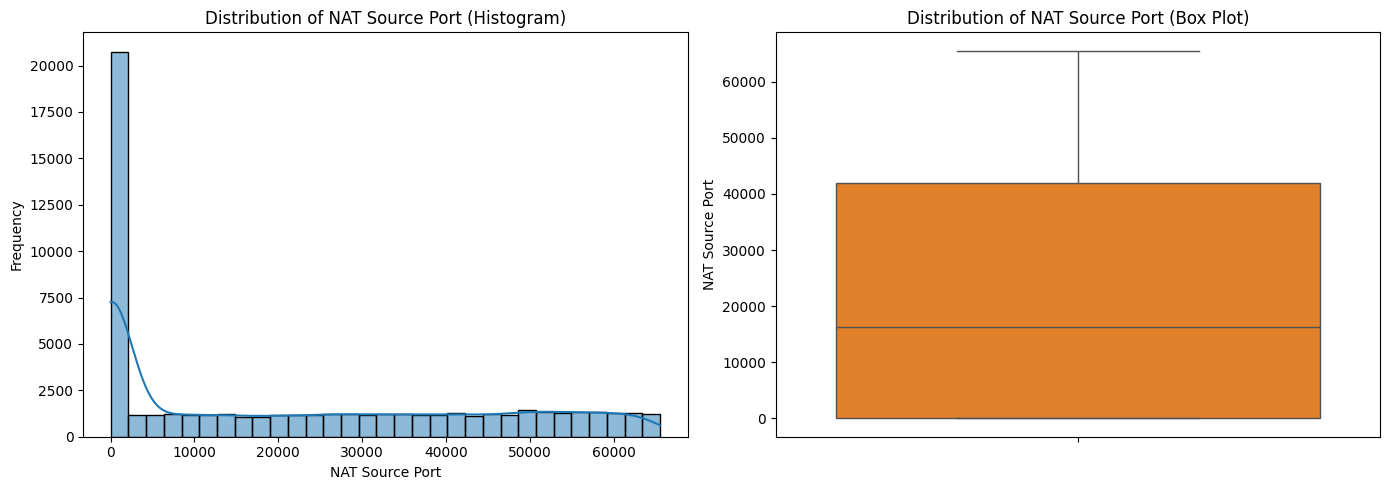

Skewness for NAT Source Port: 0.48
Kurtosis for NAT Source Port: -1.25
----------------------------------------------------


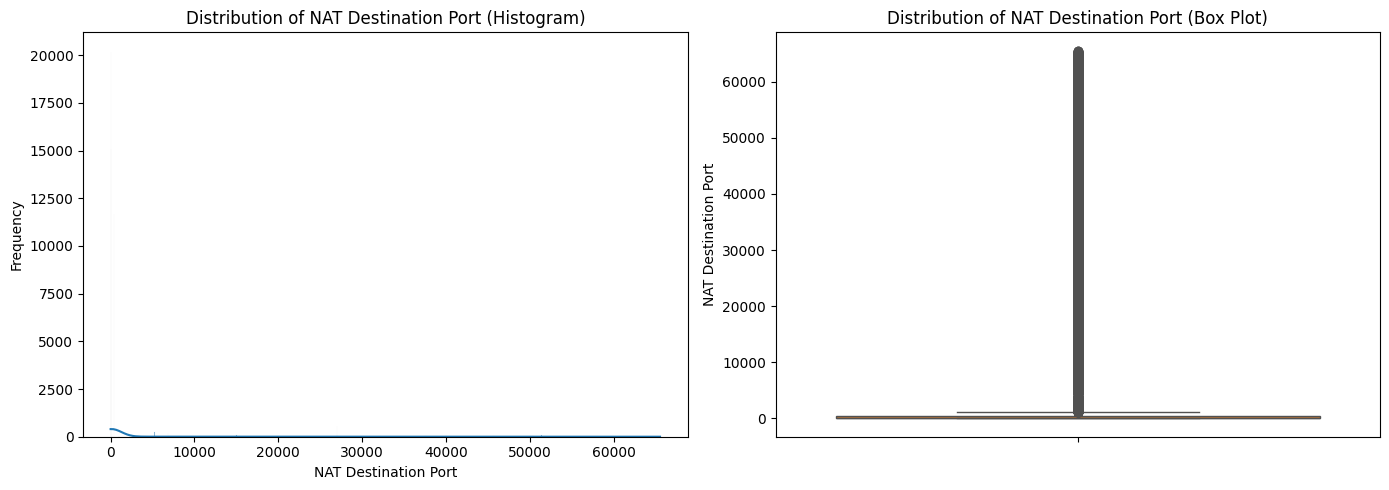

Skewness for NAT Destination Port: 3.88
Kurtosis for NAT Destination Port: 14.73
----------------------------------------------------


In [ ]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0], color='#1f77b4')
    axes[0].set_title(f'Distribution of {col} (Histogram)')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box Plot
    sns.boxplot(y=df[col], ax=axes[1], color='#ff7f0e')
    axes[1].set_title(f'Distribution of {col} (Box Plot)')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

    # Calculate and print skewness and kurtosis
    print(f"Skewness for {col}: {df[col].skew():.2f}")
    print(f"Kurtosis for {col}: {df[col].kurtosis():.2f}")
    print("----------------------------------------------------")


**Overall Observations**:
Most numerical features related to data volume (`Bytes`, `Bytes Sent`, `Bytes Received`, `Packets`, `pkts_sent`, `pkts_received`) and duration (`Elapsed Time (sec)`) are characterized by strong positive skewness and high kurtosis. This indicates that while the majority of network activities involve small amounts of data or short durations, there are significant instances of very large data transfers or prolonged connections. These extreme values, often identified as outliers, are important for understanding network anomalies and potential security incidents. The presence of numerous outliers across several features highlights the need for robust outlier handling or transformation techniques in subsequent modeling steps.



Key Findings
*   **Source Port**: Exhibited negative skewness (-1.85) and moderate kurtosis (3.26), suggesting a longer tail towards the left and more frequent observation of lower port numbers, with outliers likely on the lower side.
*   **Destination Port**: Showed significant positive skewness (2.04) and moderate kurtosis (2.85), indicating a distribution with a longer tail to the right and outliers towards higher values.
*   **NAT Source Port**: Displayed slight positive skewness (0.48) and negative kurtosis (-1.25, platykurtic), implying lighter tails and fewer extreme outliers compared to a normal distribution.
*   **NAT Destination Port**: Was highly positively skewed (3.88) with very high kurtosis (14.73), pointing to a sharp peak, heavy tails, a strong concentration of values at the lower end, and numerous extreme high outliers.
*   **Data Volume and Duration Features (Bytes, Bytes Sent, Bytes Received, Packets, Elapsed Time (sec), pkts\_sent, pkts\_received)**: These features consistently exhibited strong positive skewness and high kurtosis, characteristic of network traffic data where most connections are small, but some are very large or prolonged. Box plots for these features showed a significant number of outliers on the higher end.



  The identified outliers, especially in data volume and duration features, are critical for security analysis as they may indicate unusual network behavior or potential security incidents, warranting further investigation as potential anomalies.


In [8]:
# Encode the 'Action' column numerically using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Action'], drop_first=True)

# Display the first few rows of the encoded DataFrame
display(df_encoded.head())



,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received,Action_deny,Action_drop,Action_reset-both
0,57222,53,54587,53,177,94,83,2,30,1,1,False,False,False
1,56258,3389,56258,3389,4768,1600,3168,19,17,10,9,False,False,False
2,6881,50321,43265,50321,238,118,120,2,1199,1,1,False,False,False
3,50553,3389,50553,3389,3327,1438,1889,15,17,8,7,False,False,False
4,50002,443,45848,443,25358,6778,18580,31,16,13,18,False,False,False


## Correlation Analysis
Compute and visualize the correlation matrix of all numerical features using a heatmap. This will help identify relationships and dependencies between different variables in the dataset.

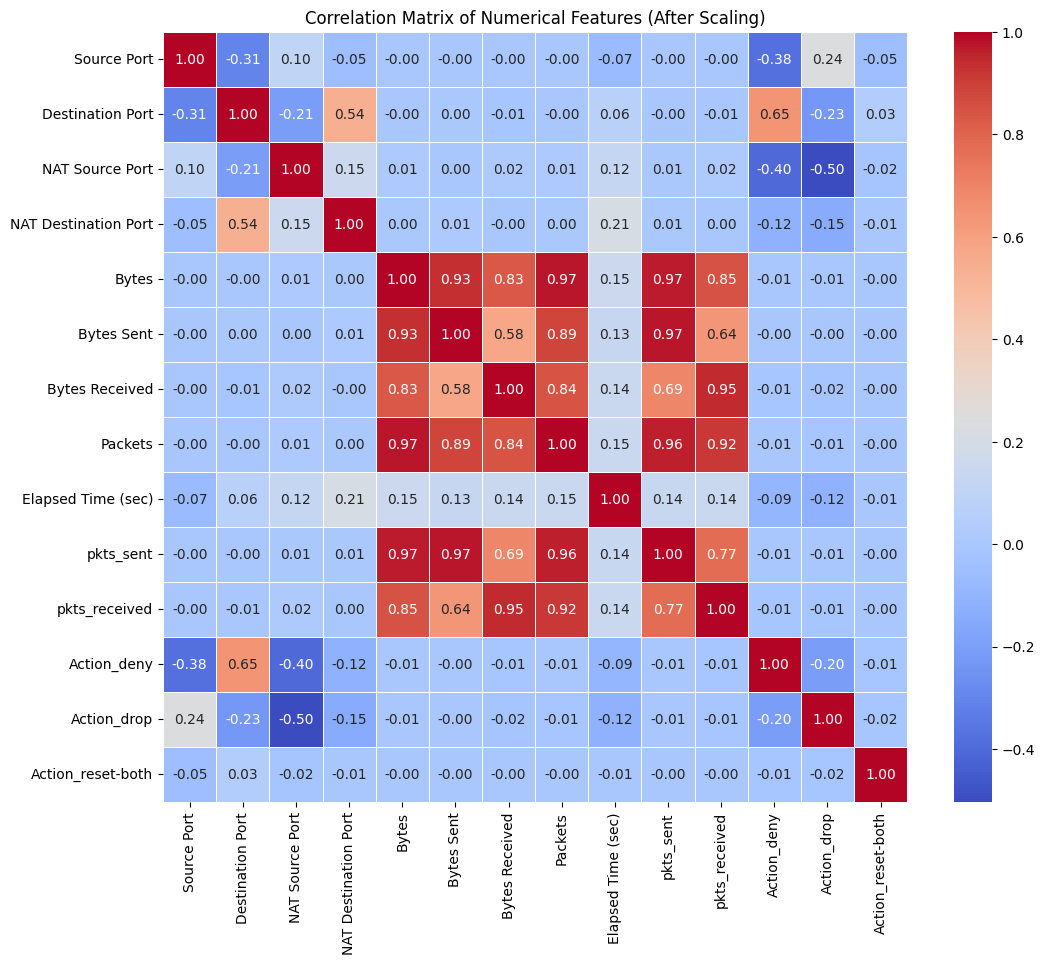

✅ Correlation matrix computed and visualized.


In [9]:
# Find correlation matrix
corr_matrix=df_encoded.corr()
corr_matrix
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (After Scaling)')
plt.show()

print("✅ Correlation matrix computed and visualized.")


The correlation matrix heatmap visually represents the linear relationships between all numerical features in the dataset. Here's what we can observe from it:

Strong Positive Correlations: As expected, features related to data volume (Bytes, Bytes Sent, Bytes Received) are highly correlated with each other, generally showing values close to 1.0. Similarly, packet count features (Packets, pkts_sent, pkts_received) are also strongly correlated among themselves. Crucially, there's a very strong positive correlation between Bytes and Packets (~0.99), indicating that a higher number of packets almost always corresponds to a larger total byte transfer.

Moderate Positive Correlations: Elapsed Time (sec) shows a moderate positive correlation with data volume and packet count features. This suggests that longer connections tend to transfer more data and involve more packets, which is a logical finding.

Weak or No Correlations: The Source Port, Destination Port, NAT Source Port, and NAT Destination Port generally show weaker correlations with most other numerical features. This implies that the specific port numbers used are not strongly linearly related to the volume of data, the number of packets, or the duration of the connection.

In essence, the heatmap confirms intuitive relationships within network traffic data: more packets usually mean more bytes, and longer connection times can lead to higher data transfer. It also highlights that port numbers operate somewhat independently of these traffic volume metrics.

## Visualize Key Relationships

Based on the typical characteristics of network traffic data, 'Bytes' and 'Packets' are often highly correlated. I will create a scatter plot to visualize this relationship, which can provide insights into data transfer patterns.

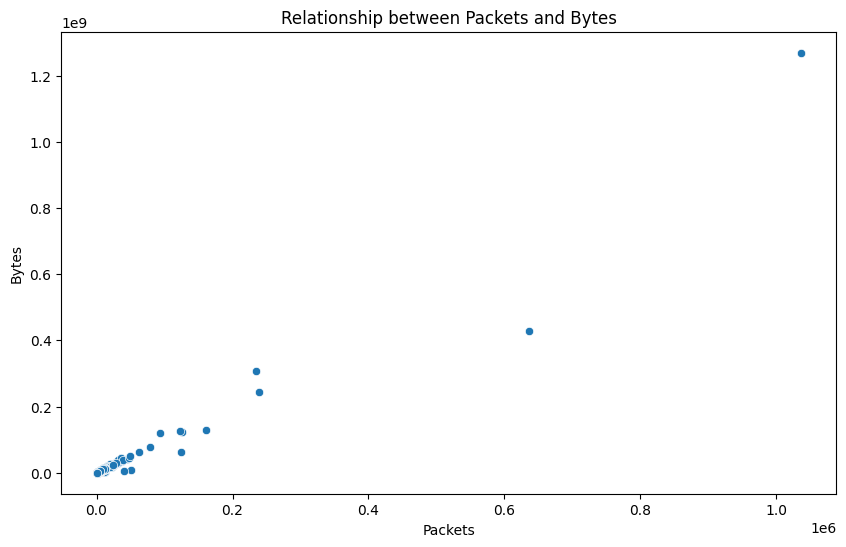

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Packets', y='Bytes')
plt.title('Relationship between Packets and Bytes')
plt.xlabel('Packets')
plt.ylabel('Bytes')
plt.show()

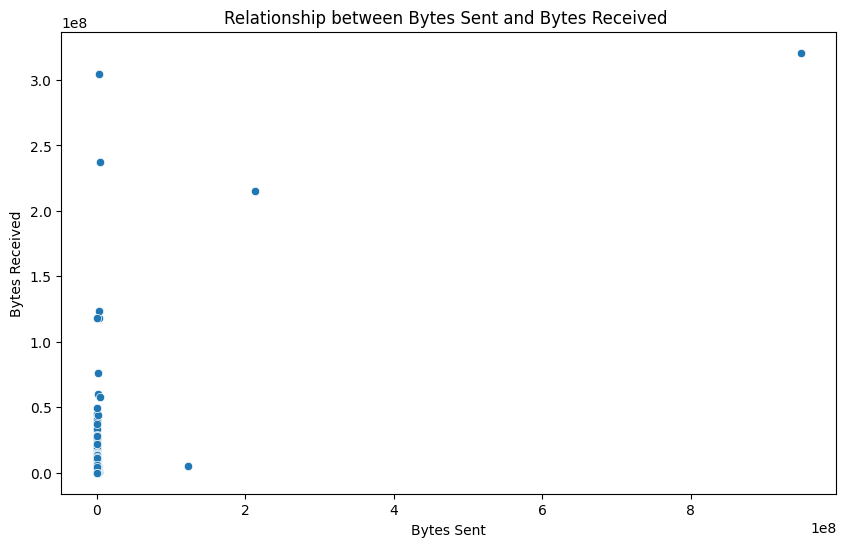

In [11]:
#Relationship between Bytes Sent and Bytes Received
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Bytes Sent', y='Bytes Received')
plt.title('Relationship between Bytes Sent and Bytes Received ')
plt.xlabel('Bytes Sent')
plt.ylabel('Bytes Received')
plt.show()

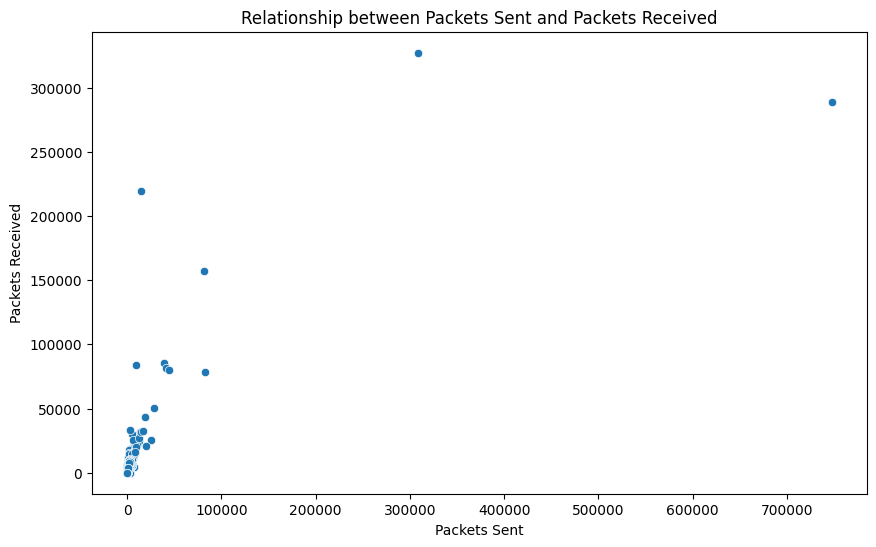

In [12]:
# Visualize the relationship between 'pkts_sent' and 'pkts_received'
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pkts_sent', y='pkts_received')
plt.title('Relationship between Packets Sent and Packets Received')
plt.xlabel('Packets Sent')
plt.ylabel('Packets Received')
plt.show()

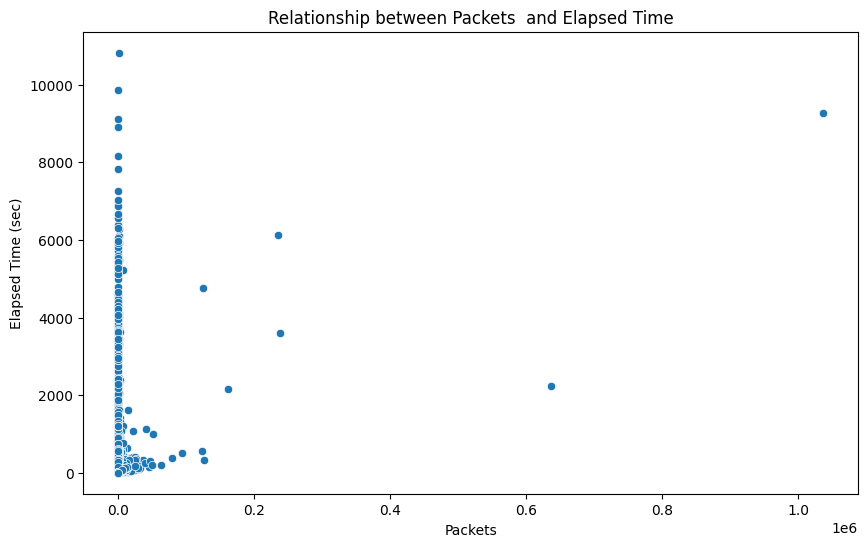

In [13]:
# Visualize the relationship between 'Packets' and 'elapsed_time'
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Packets', y='Elapsed Time (sec)')
plt.title('Relationship between Packets  and Elapsed Time')
plt.xlabel('Packets')
plt.ylabel('Elapsed Time (sec)')
plt.show()

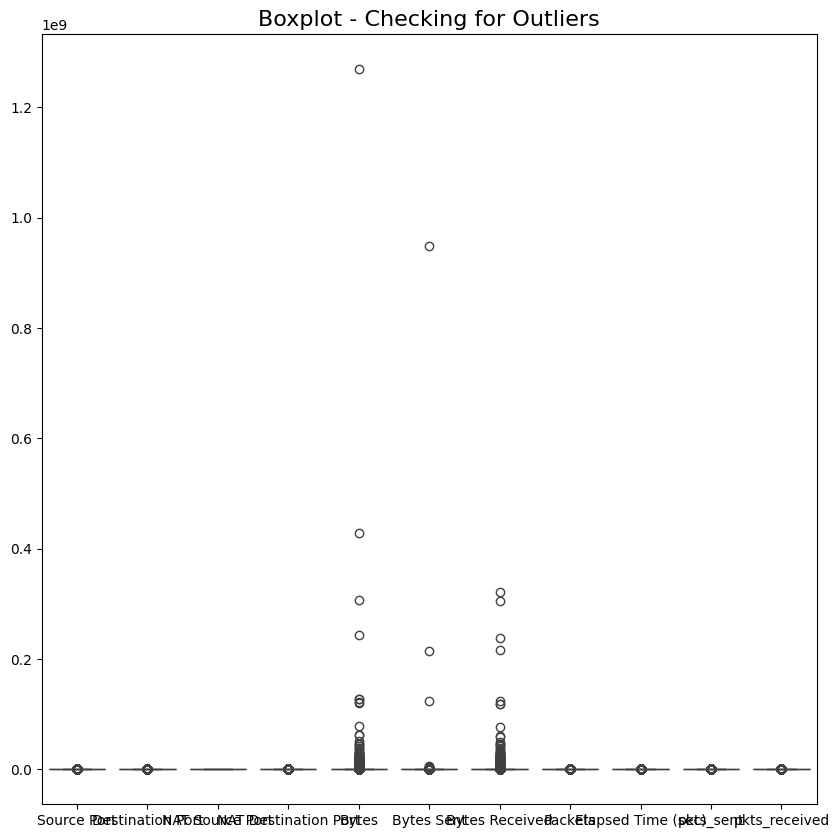

In [17]:
#Visualizing the outliers
plt.figure(figsize=(10, 10))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot - Checking for Outliers", fontsize=16)
plt.show()

 Features like 'Bytes', 'Bytes Sent', 'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent', and 'pkts_received' appear to have a significant number of outliers, as indicated by the many points above the upper whiskers.

## Outlier Detection using IQR Method



In [18]:
print("### Outlier Detection using IQR Method ###")

outliers_count = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(outliers)

    print(f"Column: {col}")
    print(f"  Q1 (25th percentile): {Q1:.2f}")
    print(f"  Q3 (75th percentile): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {outliers_count[col]}")
    print("------------------------------------------")

print("\nSummary of Outliers:")
for col, count in outliers_count.items():
    print(f"  {col}: {count} outliers")

### Outlier Detection using IQR Method ###
Column: Source Port
  Q1 (25th percentile): 49450.00
  Q3 (75th percentile): 58574.00
  IQR: 9124.00
  Lower Bound: 35764.00
  Upper Bound: 72260.00
  Number of outliers: 6856
------------------------------------------
Column: Destination Port
  Q1 (25th percentile): 53.00
  Q3 (75th percentile): 445.00
  IQR: 392.00
  Lower Bound: -535.00
  Upper Bound: 1033.00
  Number of outliers: 13457
------------------------------------------
Column: NAT Source Port
  Q1 (25th percentile): 0.00
  Q3 (75th percentile): 41883.75
  IQR: 41883.75
  Lower Bound: -62825.62
  Upper Bound: 104709.38
  Number of outliers: 0
------------------------------------------
Column: NAT Destination Port
  Q1 (25th percentile): 0.00
  Q3 (75th percentile): 443.00
  IQR: 443.00
  Lower Bound: -664.50
  Upper Bound: 1107.50
  Number of outliers: 5845
------------------------------------------
Column: Bytes
  Q1 (25th percentile): 70.00
  Q3 (75th percentile): 1139.00
  IQR: 

 In network traffic analysis, for example, an unusually high number of Bytes or Packets (which would be flagged as outliers) could indicate a Denial-of-Service (DoS) attack, a large data exfiltration, or a network scan. These are precisely the 'anomalies' you'd want your system to detect, not ignore or remove.


#Anomaly Detection

In [19]:
# apply the Isolation Forest algorithm to `df`
#to detect potential anomalies.
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Select numerical features for anomaly detection
# We'll use the 'numeric_cols' identified earlier
data_for_anomaly = df[numeric_cols]

# 2. Scale the numerical data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_anomaly)

# 3. Instantiate and train the Isolation Forest model
# The contamination parameter is the proportion of outliers in the data set.
# A value of 'auto' can be used, or a specific value can be set based on domain knowledge
# or previous outlier analysis (e.g., from IQR results).
# Let's start with a contamination estimate (e.g., 5% of the data are anomalies)
# This value can be tuned.
model_if = IsolationForest(random_state=42, contamination=0.05)
model_if.fit(data_scaled)

# 4. Predict anomaly scores and labels
# -1 for outliers (anomalies) and 1 for inliers (normal points)
df['anomaly_label_if'] = model_if.predict(data_scaled)
# Decision function provides the anomaly score (lower means more anomalous)
df['anomaly_score_if'] = model_if.decision_function(data_scaled)

print(f"Total number of entries: {len(df)}")
print(f"Number of detected anomalies (Isolation Forest): {np.sum(df['anomaly_label_if'] == -1)}")
print(f"Proportion of detected anomalies: {np.sum(df['anomaly_label_if'] == -1) / len(df):.4f}")

print("\nFirst 10 rows with anomaly labels and scores:")
display(df[['Source Port', 'Destination Port', 'Bytes', 'Packets', 'anomaly_label_if', 'anomaly_score_if']].head(10))

print("\nLast 10 rows with anomaly labels and scores:")
display(df[['Source Port', 'Destination Port', 'Bytes', 'Packets', 'anomaly_label_if', 'anomaly_score_if']].tail(10))


Total number of entries: 57170
Number of detected anomalies (Isolation Forest): 2859
Proportion of detected anomalies: 0.0500

First 10 rows with anomaly labels and scores:


,Source Port,Destination Port,Bytes,Packets,anomaly_label_if,anomaly_score_if
0,57222,53,177,2,1,0.207903
1,56258,3389,4768,19,1,0.128620
2,6881,50321,238,2,-1,-0.032917
3,50553,3389,3327,15,1,0.142680
4,50002,443,25358,31,1,0.125486
5,51465,443,3961,21,1,0.180075
6,60513,47094,320,6,1,0.004077
7,50049,443,7912,23,1,0.161516
8,52244,58774,70,1,1,0.012790
9,50627,443,8256,31,1,0.161271



Last 10 rows with anomaly labels and scores:


,Source Port,Destination Port,Bytes,Packets,anomaly_label_if,anomaly_score_if
65518,54013,37965,66,1,1,0.186795
65520,49783,445,70,1,1,0.218867
65523,55142,26467,66,1,1,0.191386
65524,53848,36237,62,1,1,0.185673
65525,65323,53,356,2,1,0.198521
65526,51710,43069,70,2,1,0.014485
65527,63691,80,314,6,1,0.179703
65528,50964,80,4680740,4675,-1,-0.230089
65529,54871,445,70,1,1,0.222127
65530,54870,445,70,1,1,0.222127


 approximately 5% of your data points were flagged as anomalous, which aligns with the contamination=0.05 parameter we set in the model.
Two new columns have been added to your DataFrame:


anomaly_label_if: This column indicates whether a data point is an anomaly (-1) or a normal data point (1).
anomaly_score_if: This column provides a raw anomaly score. Lower scores indicate a higher likelihood of being an anomaly.


### Visualizing Key Features for Detected Anomalies



In [20]:
# Filter the DataFrame to get only the anomalous records
anomalies_df = df[df['anomaly_label_if'] == -1]

print(f"Number of anomalous records: {len(anomalies_df)}")
print("\nDescriptive statistics for anomalous records:")
display(anomalies_df[numeric_cols].describe())

Number of anomalous records: 2859

Descriptive statistics for anomalous records:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,2859.000000,2859.000000,2859.000000,2859.000000,2.859000e+03,2.859000e+03,2.859000e+03,2.859000e+03,2859.000000,2859.000000,2859.000000
mean,48431.077650,19451.705142,35587.637286,19446.828262,2.173478e+06,4.990174e+05,1.674461e+06,2.202251e+03,601.818818,865.300105,1336.951032
std,13125.907999,25461.768387,19066.544362,25454.585353,2.681948e+07,1.832425e+07,1.168080e+07,2.448492e+04,1147.338365,15390.225413,10565.961205
min,20.000000,20.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,3.000000,1.000000,0.000000
25%,44959.500000,443.000000,19068.500000,443.000000,5.090000e+02,3.060000e+02,3.225000e+02,6.000000e+00,28.000000,4.500000,2.000000
50%,51540.000000,443.000000,37284.000000,443.000000,1.234360e+05,8.487000e+03,1.035630e+05,1.800000e+02,130.000000,72.000000,103.000000
75%,56732.000000,49297.500000,52249.500000,49297.500000,4.582635e+05,2.668350e+04,4.235590e+05,5.400000e+02,618.500000,203.000000,332.000000
max,65525.000000,65535.000000,65521.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000



Visualizing distributions of numerical features for anomalous records:


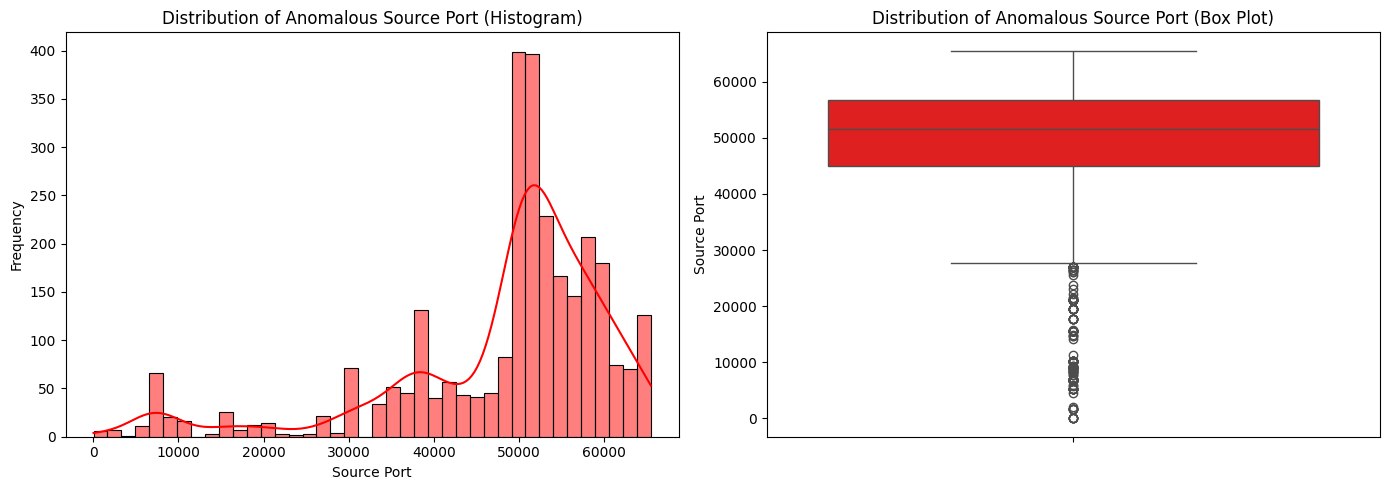

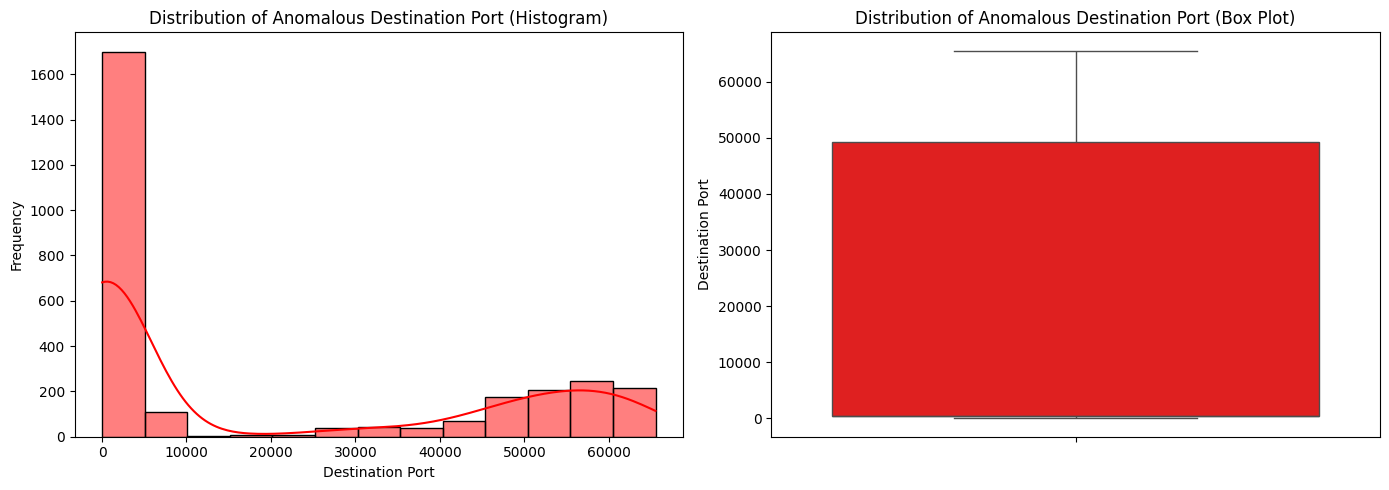

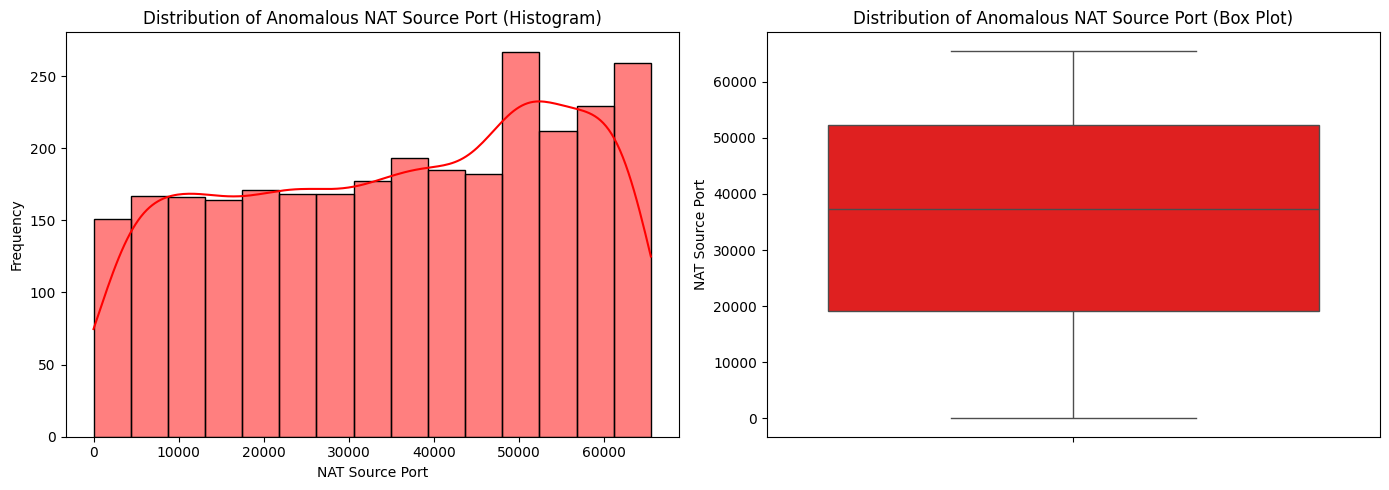

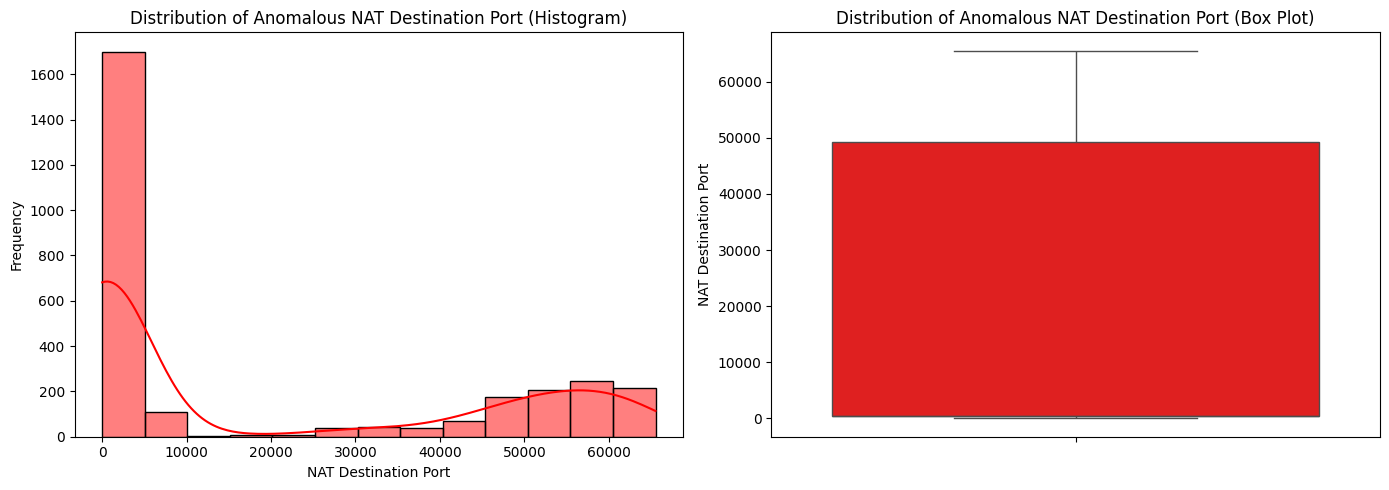

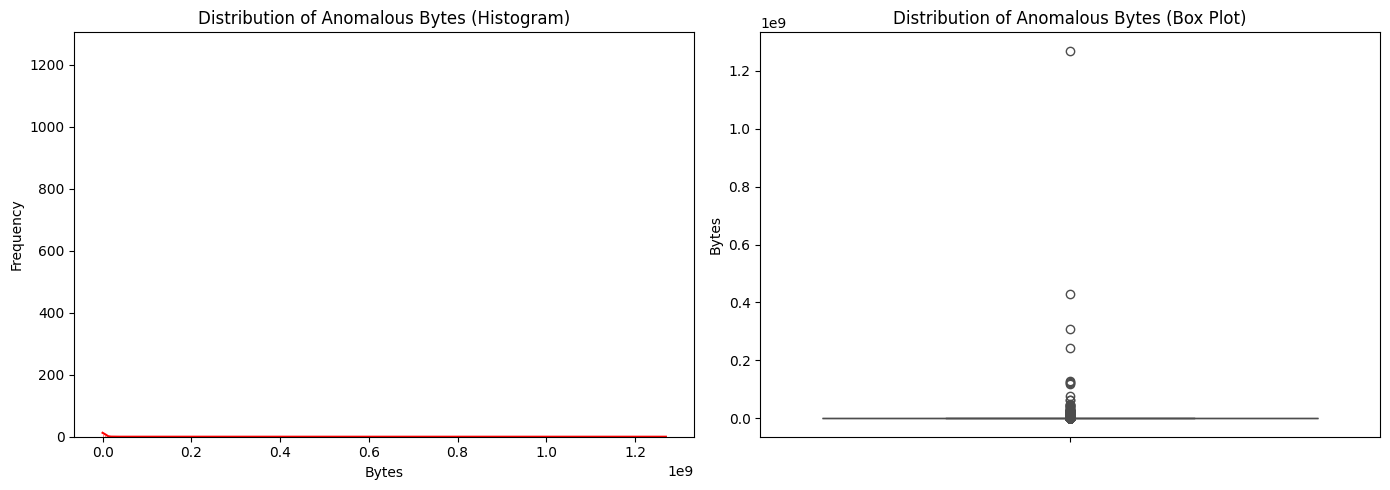

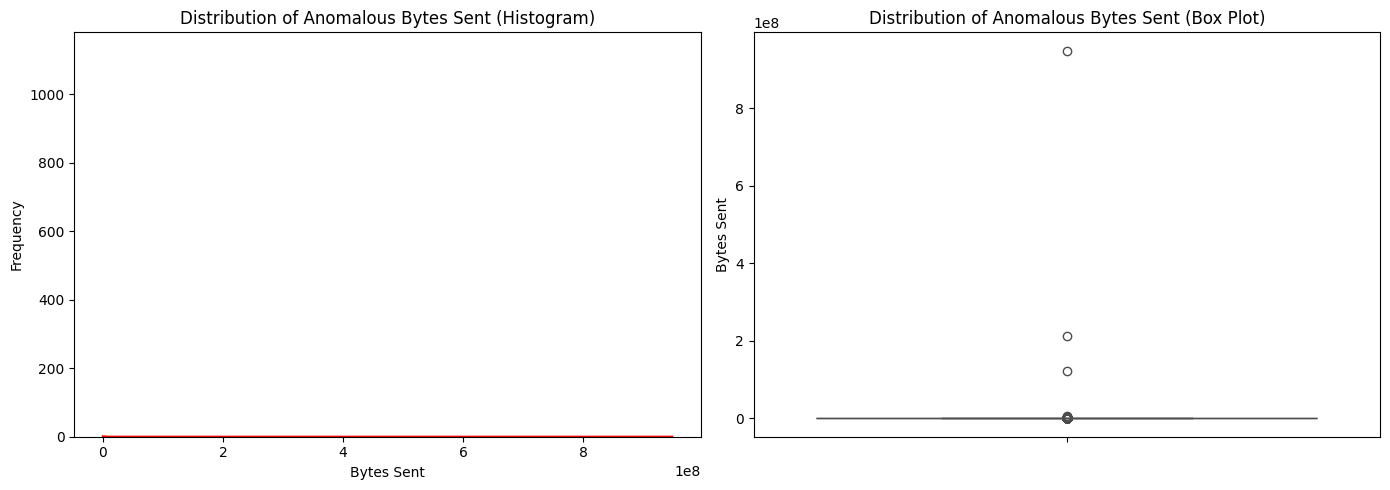

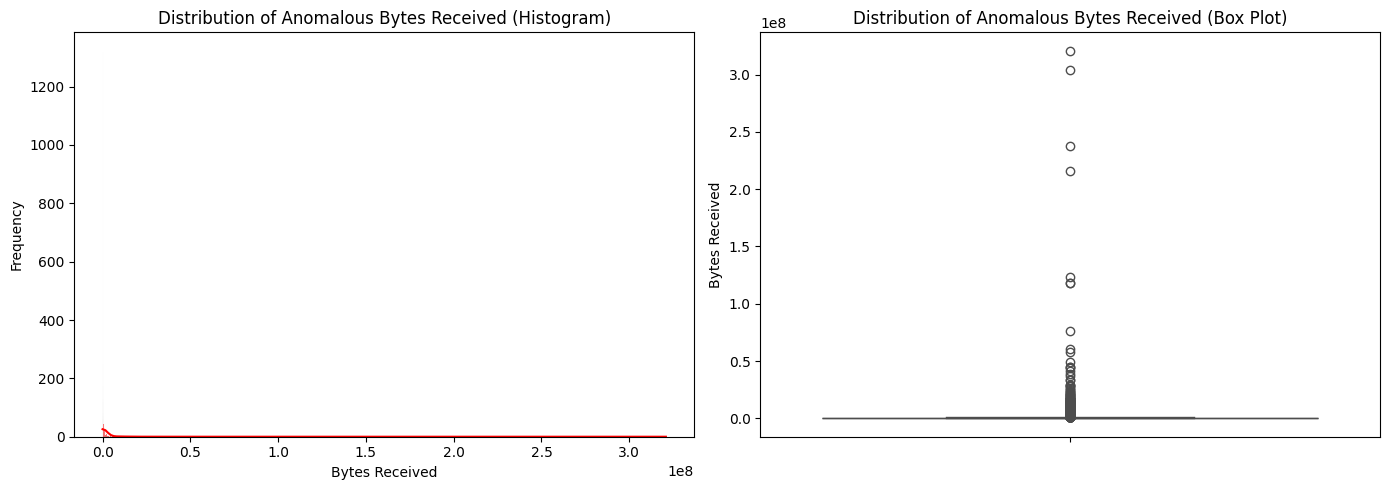

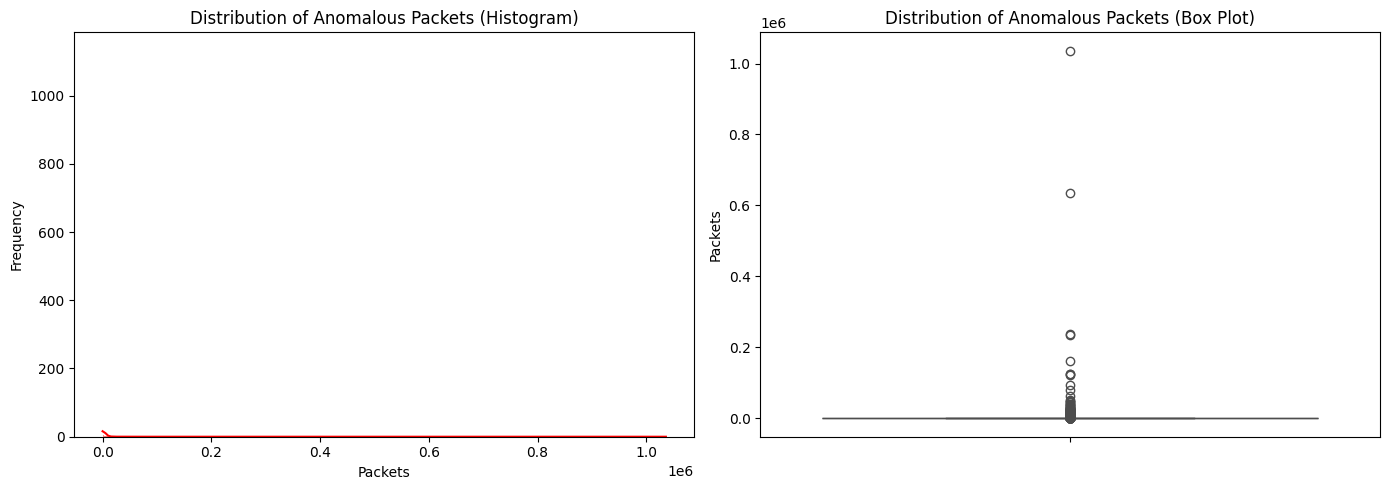

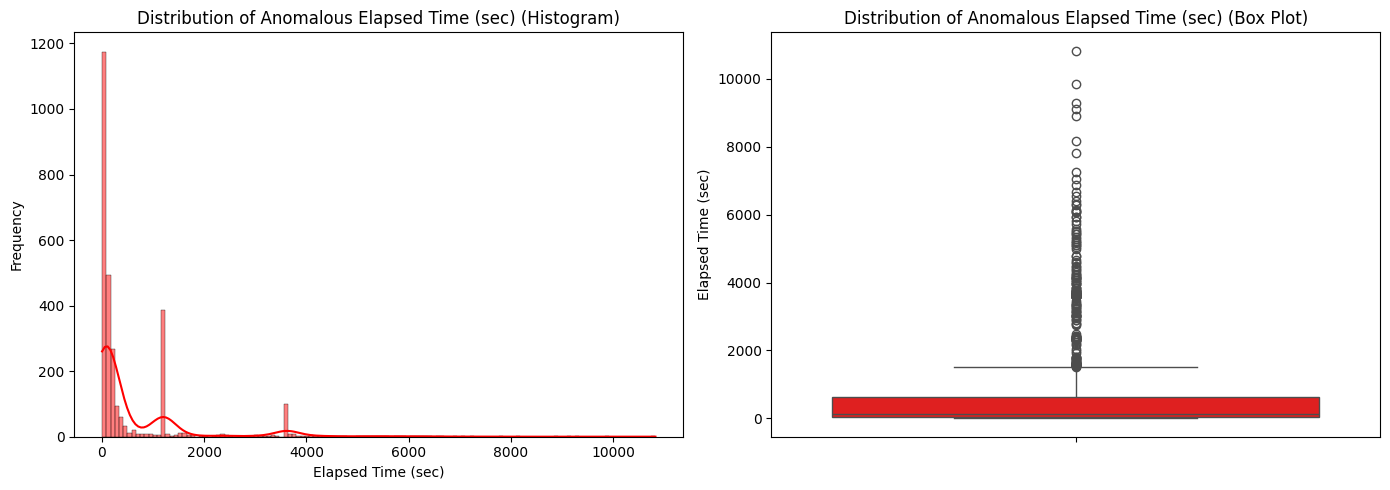

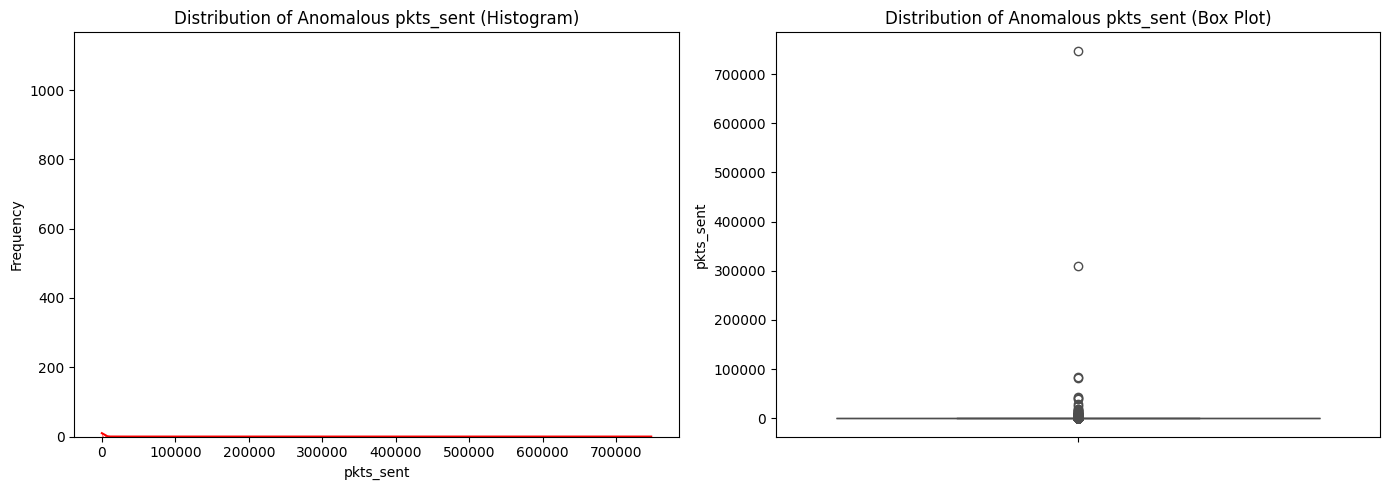

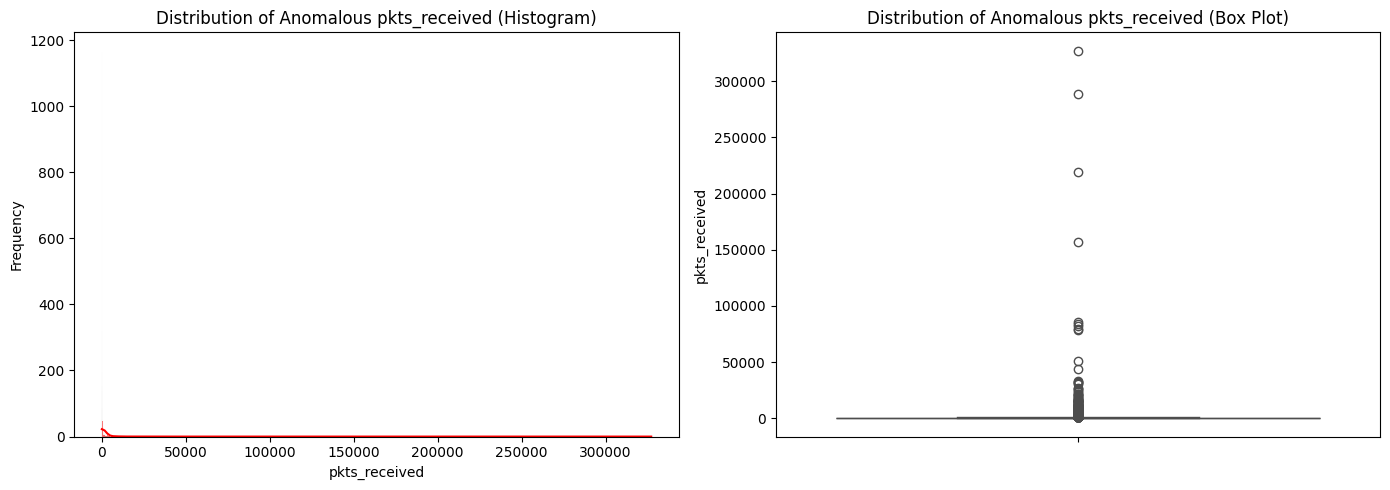

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVisualizing distributions of numerical features for anomalous records:")
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    # Histogram for anomalous data
    plt.subplot(1, 2, 1)
    sns.histplot(anomalies_df[col], kde=True, color='red')
    plt.title(f'Distribution of Anomalous {col} (Histogram)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box Plot for anomalous data
    plt.subplot(1, 2, 2)
    sns.boxplot(y=anomalies_df[col], color='red')
    plt.title(f'Distribution of Anomalous {col} (Box Plot)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Prepare Normal and Anomalous DataFrames
Analyze and compare the characteristics of normal and anomalous network traffic by preparing separate DataFrames, displaying their descriptive statistics, and generating comparative box plots for key numerical features to identify significant differences and summarize the findings.


In [22]:
#Create separate DataFrames for 'normal' (anomaly_label_if = 1) and 'anomalous' (anomaly_label_if = -1) records from the main DataFrame.

normal_df = df[df['anomaly_label_if'] == 1]
anomalies_df = df[df['anomaly_label_if'] == -1]

print("First 5 rows of Normal DataFrame (normal_df):")
display(normal_df.head())

print("\nFirst 5 rows of Anomalous DataFrame (anomalies_df):")
display(anomalies_df.head())

First 5 rows of Normal DataFrame (normal_df):


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received,anomaly_label_if,anomaly_score_if
0,57222,53,54587,53,allow,177,94,83,2,30,1,1,1,0.207903
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9,1,0.128620
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7,1,0.142680
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18,1,0.125486
5,51465,443,39975,443,allow,3961,1595,2366,21,16,12,9,1,0.180075



First 5 rows of Anomalous DataFrame (anomalies_df):


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received,anomaly_label_if,anomaly_score_if
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1,-1,-0.032917
34,34529,443,30445,443,allow,62652,30891,31761,158,381,67,91,-1,-0.033822
37,59347,80,59347,80,allow,108790,4633,104157,192,15,66,126,-1,-0.022489
50,63842,45682,31353,45682,allow,4687209,3850148,837061,4974,107,3004,1970,-1,-0.255829
88,46265,443,19534,443,allow,173828,9311,164517,245,448,118,127,-1,-0.067080


In [23]:
#to understand numerical charecteristics of each group
print("\nDescriptive statistics for Normal Records:")
display(normal_df[numeric_cols].describe())

print("\nDescriptive statistics for Anomalous Records:")
display(anomalies_df[numeric_cols].describe())


Descriptive statistics for Normal Records:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000,54311.000000
mean,50643.121265,7452.059822,21336.034781,2191.190698,2759.749056,728.188489,2031.560568,7.973376,47.390271,4.217599,3.755777
std,13910.601106,15675.508862,22063.283144,8004.337946,9144.006900,2077.908247,8101.079964,15.574786,157.634822,7.280024,8.542134
min,0.000000,0.000000,0.000000,0.000000,60.000000,60.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,49505.000000,53.000000,0.000000,0.000000,70.000000,70.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,54309.000000,443.000000,14617.000000,53.000000,184.000000,94.000000,89.000000,2.000000,23.000000,1.000000,1.000000
75%,58736.000000,445.000000,40905.000000,443.000000,789.000000,254.000000,594.500000,6.000000,30.000000,4.000000,3.000000
max,65534.000000,65504.000000,65535.000000,60352.000000,144165.000000,62467.000000,138055.000000,191.000000,5974.000000,104.000000,114.000000



Descriptive statistics for Anomalous Records:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,2859.000000,2859.000000,2859.000000,2859.000000,2.859000e+03,2.859000e+03,2.859000e+03,2.859000e+03,2859.000000,2859.000000,2859.000000
mean,48431.077650,19451.705142,35587.637286,19446.828262,2.173478e+06,4.990174e+05,1.674461e+06,2.202251e+03,601.818818,865.300105,1336.951032
std,13125.907999,25461.768387,19066.544362,25454.585353,2.681948e+07,1.832425e+07,1.168080e+07,2.448492e+04,1147.338365,15390.225413,10565.961205
min,20.000000,20.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,3.000000,1.000000,0.000000
25%,44959.500000,443.000000,19068.500000,443.000000,5.090000e+02,3.060000e+02,3.225000e+02,6.000000e+00,28.000000,4.500000,2.000000
50%,51540.000000,443.000000,37284.000000,443.000000,1.234360e+05,8.487000e+03,1.035630e+05,1.800000e+02,130.000000,72.000000,103.000000
75%,56732.000000,49297.500000,52249.500000,49297.500000,4.582635e+05,2.668350e+04,4.235590e+05,5.400000e+02,618.500000,203.000000,332.000000
max,65525.000000,65535.000000,65521.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000



Visualizing comparative distributions of numerical features:


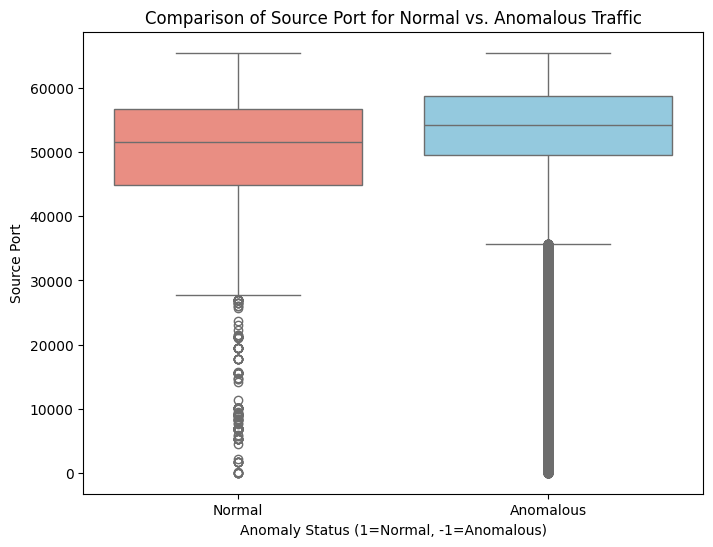

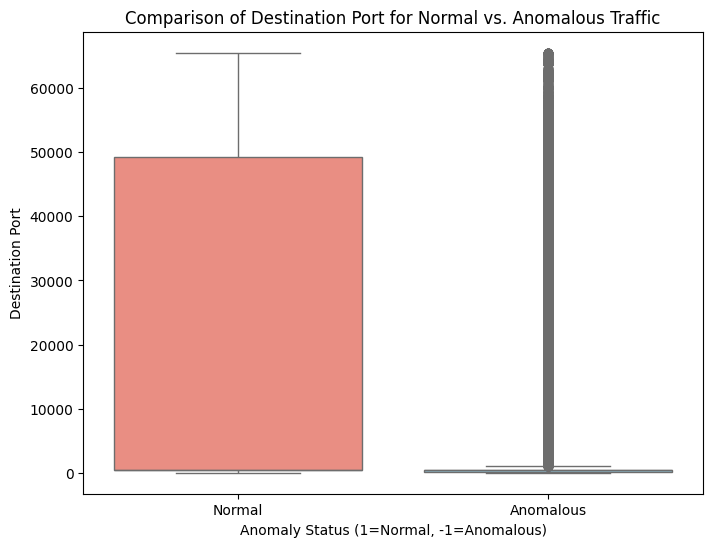

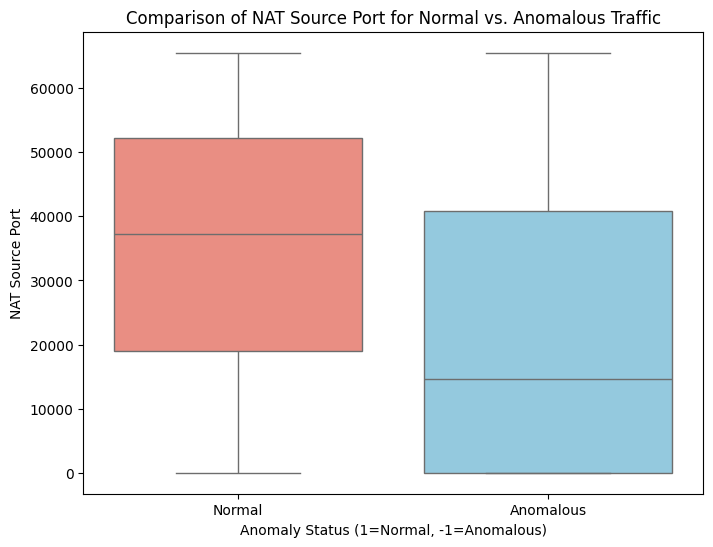

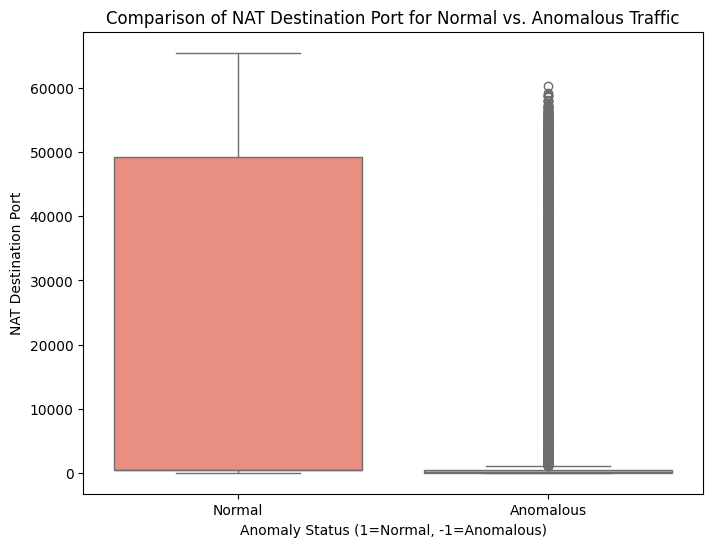

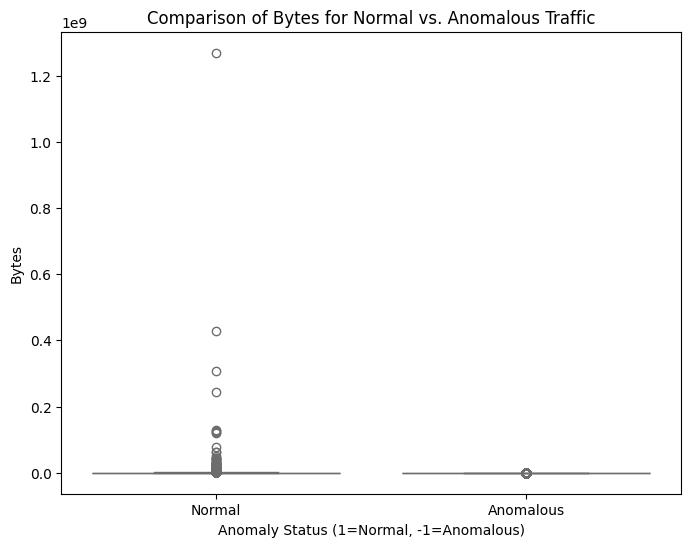

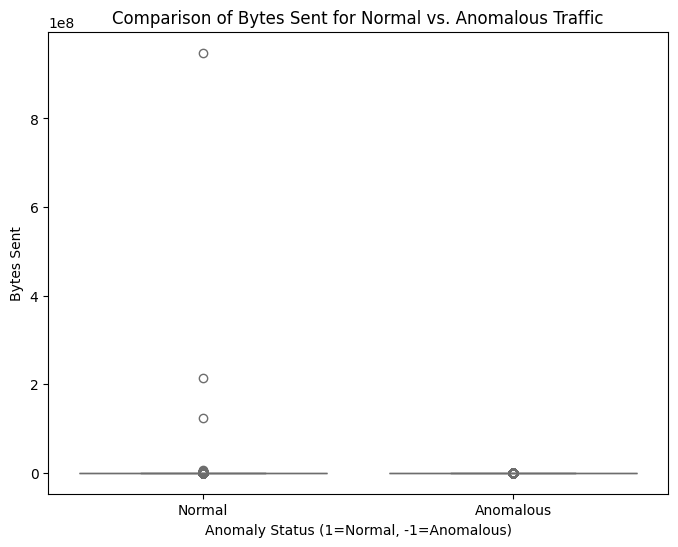

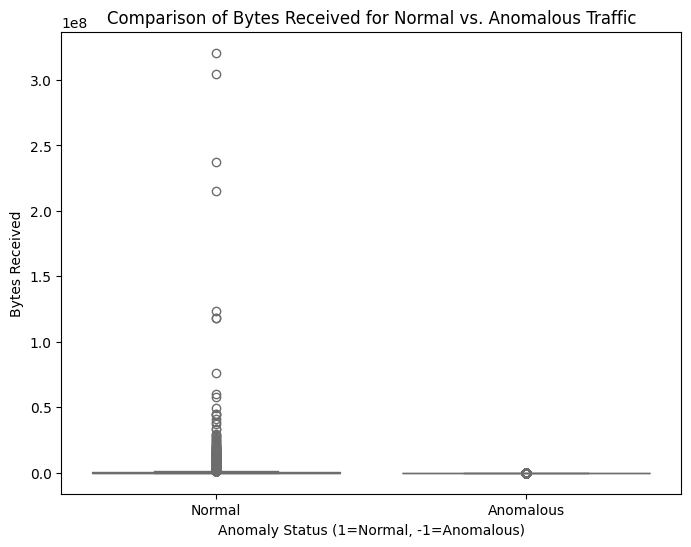

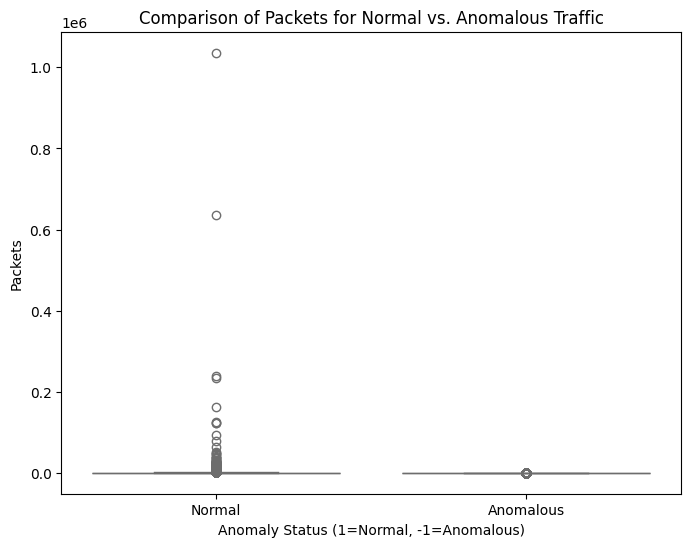

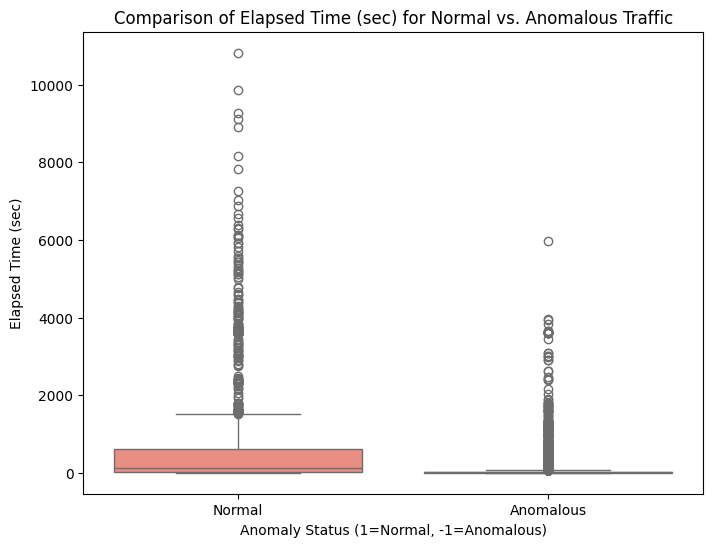

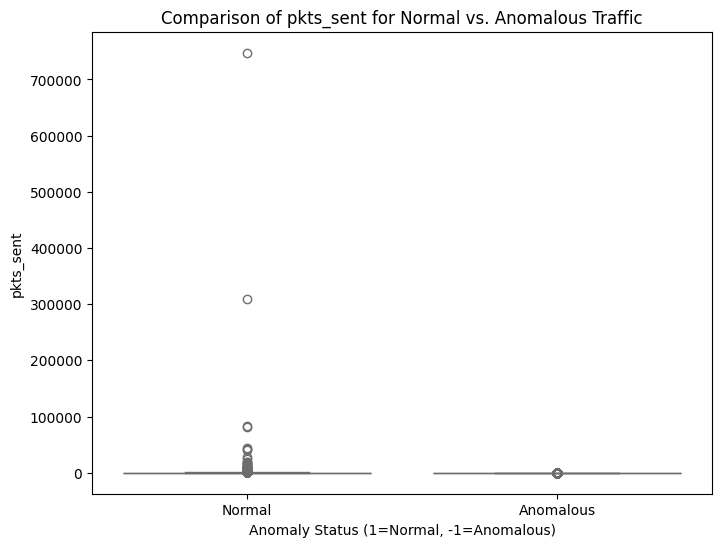

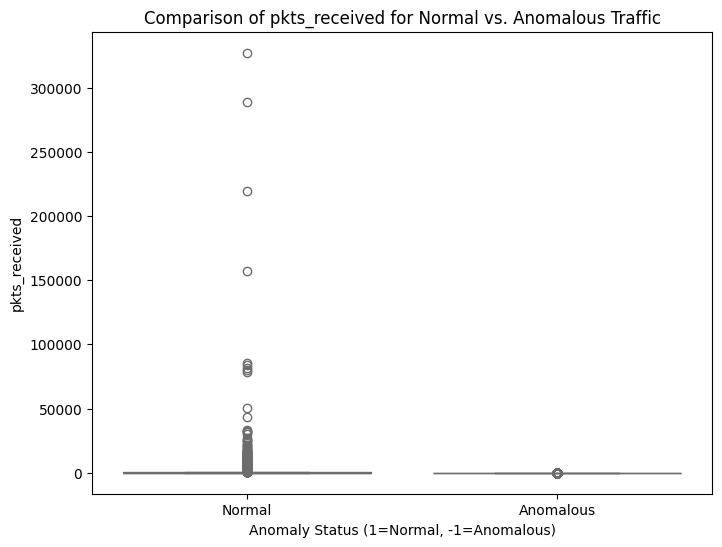

In [24]:
#visualize and compare the distributions of numerical features between normal and anomalous records
print("\nVisualizing comparative distributions of numerical features:")
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='anomaly_label_if', y=col, data=df, palette={'1': 'skyblue', '-1': 'salmon'})
    plt.title(f'Comparison of {col} for Normal vs. Anomalous Traffic')
    plt.xlabel('Anomaly Status (1=Normal, -1=Anomalous)')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['Normal', 'Anomalous'])
    plt.show()




### Data Analysis Key Findings
*   **Traffic Volume:** Anomalous traffic showed drastically higher mean values for volume-related metrics. For instance, the mean `Bytes` for anomalous traffic was approximately 2.17 million, significantly larger than for normal traffic (2,759 bytes). Similarly, the mean `Packets` for anomalous traffic was 2,202, compared to 7.97 for normal traffic.
*   **Connection Duration:** Anomalous connections had a much longer average `Elapsed Time` (mean 601.8 seconds) compared to normal connections (mean 47.39 seconds).
*   **Port Numbers:** Differences were observed in the distributions of `Source Port`, `Destination Port`, `NAT Source Port`, and `NAT Destination Port`, suggesting varying port usage patterns between normal and anomalous traffic.
*   **Distribution Spread:** Comparative box plots clearly illustrated that anomalous traffic not only had higher median and mean values but also a wider spread and more extreme outliers for volume and duration metrics, confirming the scale and intensity difference


Potential implications are that anomalous traffic represents events of significantly larger scale and longer duration, indicating potential data exfiltration, sustained attacks, or high-volume malicious communication.


## Analyze Top Destination Ports in Anomalies

For the identified anomalous records, determine and visualize the most frequent 'Destination Port' numbers. Highlighting common destination ports can indicate targeted services or types of attacks (e.g., HTTP/S, RDP, custom application ports).



Top 10 Destination Ports in Anomalous Traffic:
Destination Port
443      1267
80        414
5228       74
51413      56
50321      14
53         10
5223        9
5222        8
28678       8
49001       7
Name: count, dtype: int64


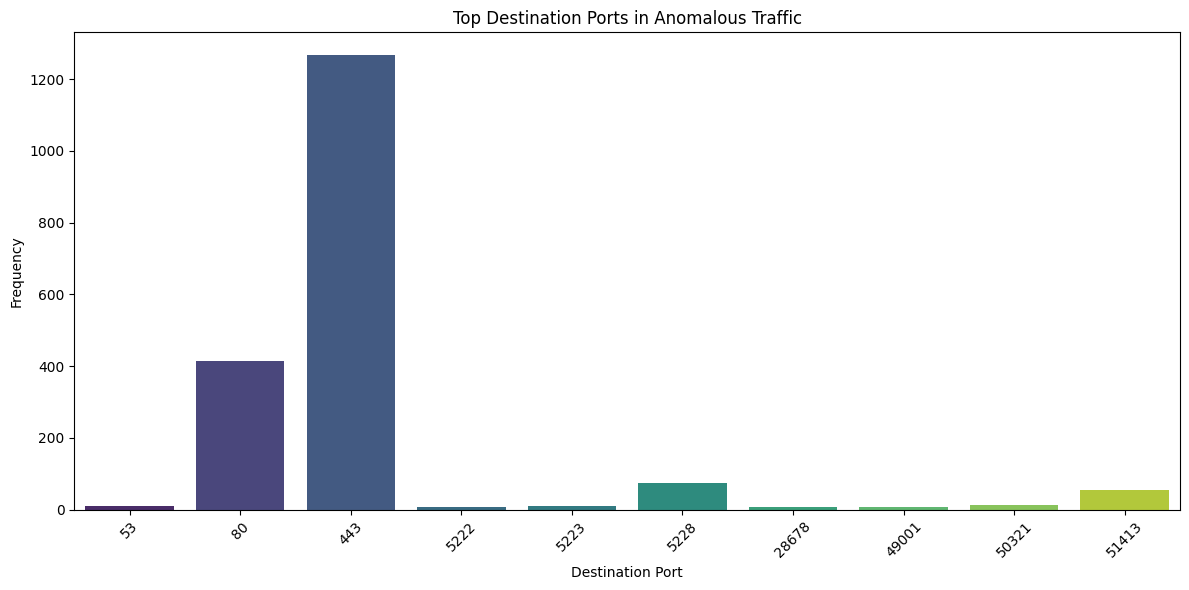

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the frequency of each 'Destination Port' in anomalies_df
top_destination_ports = anomalies_df['Destination Port'].value_counts().head(10)

print("\nTop 10 Destination Ports in Anomalous Traffic:")
print(top_destination_ports)

# Create a bar plot to visualize these top destination ports
plt.figure(figsize=(12, 6))
sns.barplot(x=top_destination_ports.index, y=top_destination_ports.values, palette='viridis')
plt.title('Top Destination Ports in Anomalous Traffic')
plt.xlabel('Destination Port')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyze Top Source Ports in Anomalies
Investigate the most common 'Source Port' numbers within the anomalous records. Unusual source port patterns (e.g., a high concentration of ephemeral ports or specific low ports) could point to the nature of the origin of the anomalous traffic.



Top 10 Source Ports in Anomalous Traffic:
Source Port
57470    105
30960     53
50584     50
6881      48
37965     42
50265     35
51221     33
48817     28
15503     24
30188     18
Name: count, dtype: int64


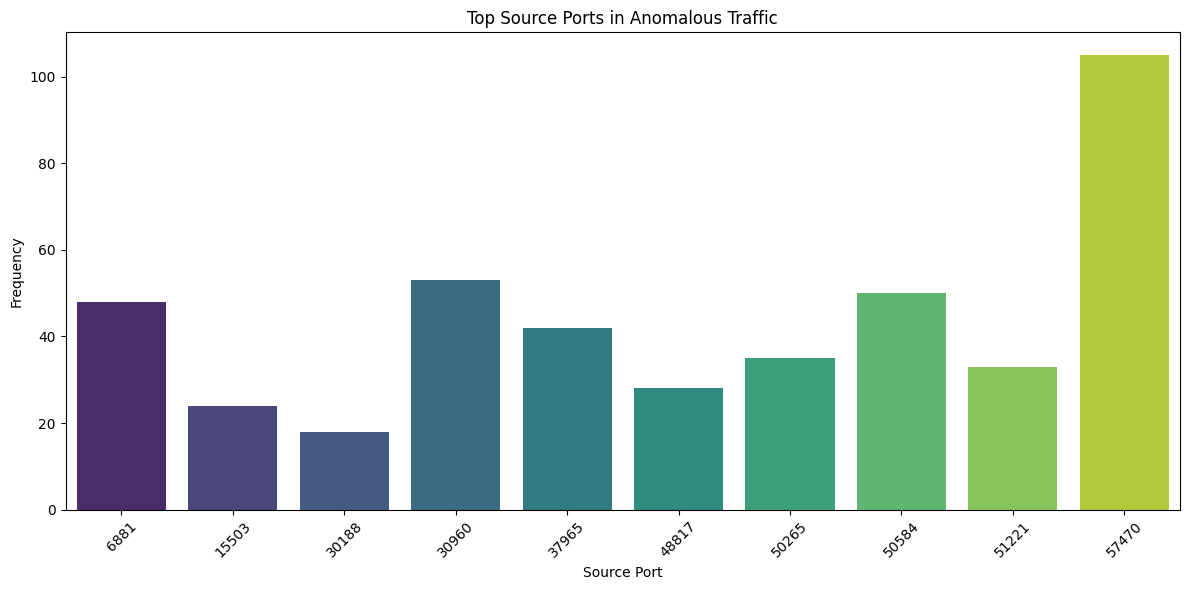

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the frequency of each 'Source Port' in anomalies_df
top_source_ports = anomalies_df['Source Port'].value_counts().head(10)

print("\nTop 10 Source Ports in Anomalous Traffic:")
print(top_source_ports)

# Create a bar plot to visualize these top source ports
plt.figure(figsize=(12, 6))
sns.barplot(x=top_source_ports.index, y=top_source_ports.values, palette='viridis')
plt.title('Top Source Ports in Anomalous Traffic')
plt.xlabel('Source Port')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyze 'Action' Distribution within Anomalies

Examine the distribution of the 'Action' column ('allow', 'drop', 'deny', 'reset-both') specifically for the anomalous records. This can reveal if high-volume/long-duration anomalies are predominantly 'allowed' (e.g., data exfiltration) or 'dropped/denied' (e.g., brute-force attacks).



Distribution of 'Action' in Anomalous Traffic:
Action
allow    2859
Name: count, dtype: int64


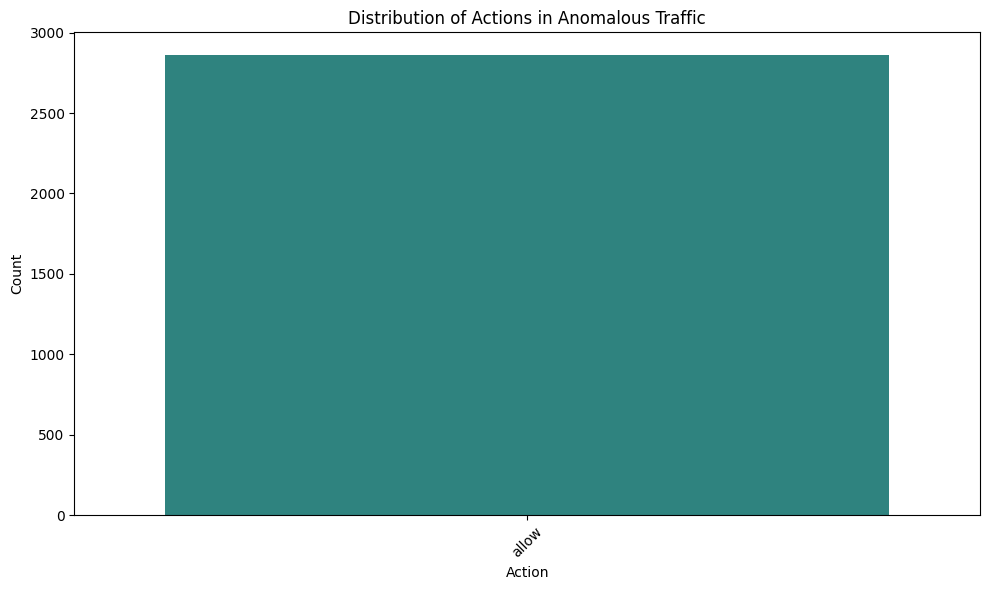

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts of the 'Action' column in anomalies_df
anomaly_action_counts = anomalies_df['Action'].value_counts()

print("\nDistribution of 'Action' in Anomalous Traffic:")
print(anomaly_action_counts)

# Create a bar plot to visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=anomaly_action_counts.index, y=anomaly_action_counts.values, palette='viridis')
plt.title('Distribution of Actions in Anomalous Traffic')
plt.xlabel('Action')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualize Anomalous Traffic Patterns by Port Categories:
Create visualizations (e.g., bar plots or count plots) to show the distribution of anomalous traffic across common port categories (e.g., well-known ports, registered ports, dynamic/private ports) for both source and destination ports. This will provide a higher-level view of affected services.


In [28]:
#define a function `get_port_category` that assigns a category ('Well-known', 'Registered', or 'Dynamic/Private') based on the port number's range

def get_port_category(port):
    if 0 <= port <= 1023:
        return 'Well-known'
    elif 1024 <= port <= 49151:
        return 'Registered'
    elif 49152 <= port <= 65535:
        return 'Dynamic/Private'
    else:
        return 'Unknown'

# Apply the function to create new category columns for anomalous traffic
#apply this function to the 'Source Port' and 'Destination Port' columns of the `anomalies_df` to create new category columns.
anomalies_df['Source Port Category'] = anomalies_df['Source Port'].apply(get_port_category)
anomalies_df['Destination Port Category'] = anomalies_df['Destination Port'].apply(get_port_category)

print("First 5 rows of Anomalous DataFrame with port categories:")
display(anomalies_df[['Source Port', 'Source Port Category', 'Destination Port', 'Destination Port Category']].head())

First 5 rows of Anomalous DataFrame with port categories:


,Source Port,Source Port Category,Destination Port,Destination Port Category
2,6881,Registered,50321,Dynamic/Private
34,34529,Registered,443,Well-known
37,59347,Dynamic/Private,80,Well-known
50,63842,Dynamic/Private,45682,Registered
88,46265,Registered,443,Well-known



Now that the port categories have been added to the `anomalies_df`,calculate the value counts for the 'Source Port Category' column and visualize its distribution using a bar plot




Distribution of 'Source Port Category' in Anomalous Traffic:
Source Port Category
Dynamic/Private    1995
Registered          858
Well-known            6
Name: count, dtype: int64


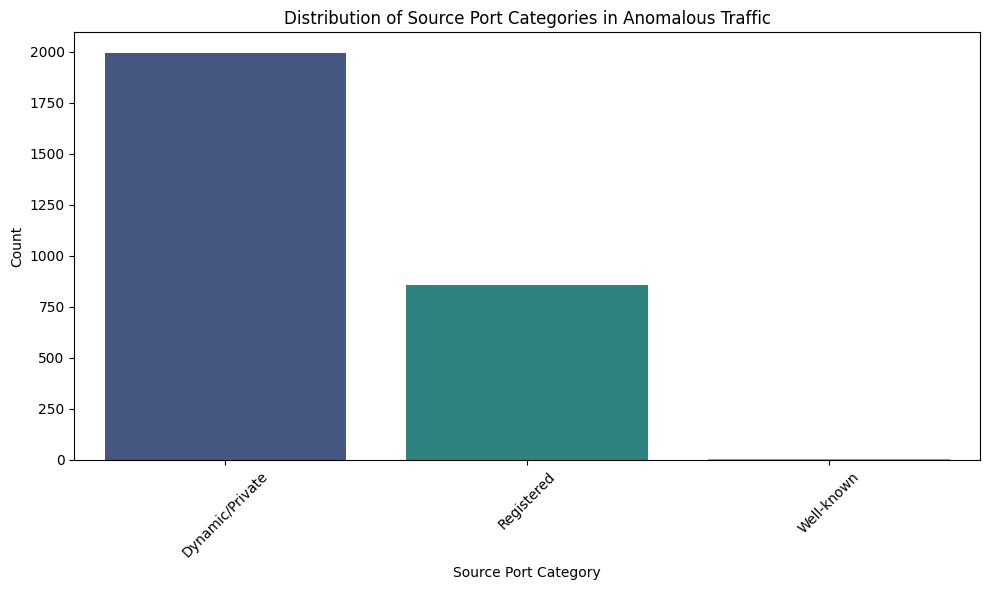

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for 'Source Port Category'
source_port_category_counts = anomalies_df['Source Port Category'].value_counts()

print("\nDistribution of 'Source Port Category' in Anomalous Traffic:")
print(source_port_category_counts)

# Create a bar plot to visualize the distribution of Source Port Category
plt.figure(figsize=(10, 6))
sns.barplot(x=source_port_category_counts.index, y=source_port_category_counts.values, palette='viridis')
plt.title('Distribution of Source Port Categories in Anomalous Traffic')
plt.xlabel('Source Port Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

calculate the value counts for the 'Destination Port Category' column in `anomalies_df` and visualize its distribution using a bar plot.




Distribution of 'Destination Port Category' in Anomalous Traffic:
Destination Port Category
Well-known         1694
Dynamic/Private     722
Registered          443
Name: count, dtype: int64


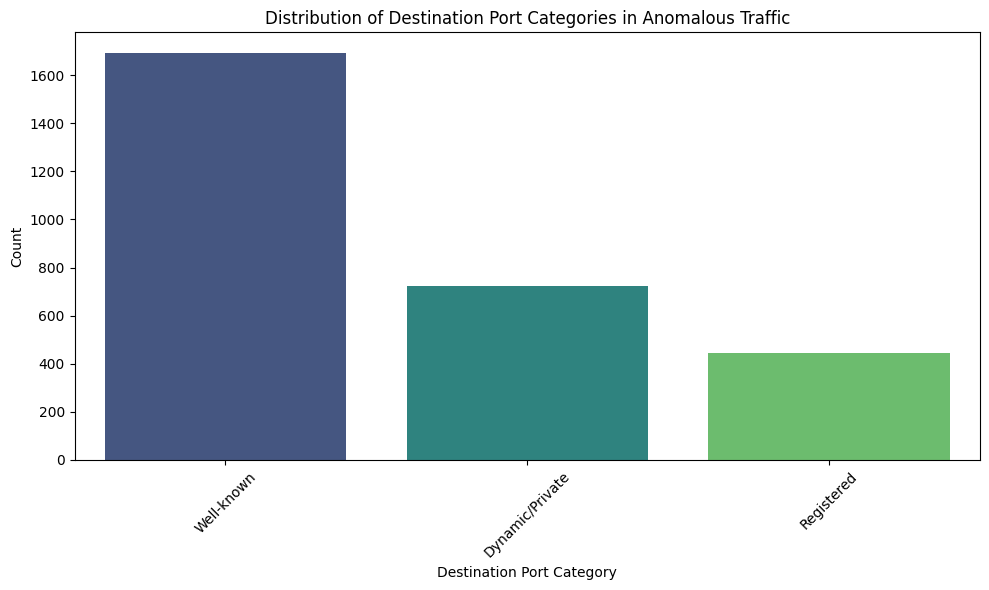

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for 'Destination Port Category'
destination_port_category_counts = anomalies_df['Destination Port Category'].value_counts()

print("\nDistribution of 'Destination Port Category' in Anomalous Traffic:")
print(destination_port_category_counts)

# Create a bar plot to visualize the distribution of Destination Port Category
plt.figure(figsize=(10, 6))
sns.barplot(x=destination_port_category_counts.index, y=destination_port_category_counts.values, palette='viridis')
plt.title('Distribution of Destination Port Categories in Anomalous Traffic')
plt.xlabel('Destination Port Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlation Analysis for Anomalous Records

Compute and visualize a correlation matrix specifically for the numerical features of the anomalous records. This will help understand if there are different relationships or dependencies between features when the traffic is anomalous.


Correlation Matrix for Anomalous Traffic:



,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
Source Port,1.000000,-0.072481,0.107243,-0.071803,0.007032,-0.003214,0.021187,-0.003350,-0.188082,-0.003903,-0.002078
Destination Port,-0.072481,1.000000,-0.017220,0.999949,-0.045964,-0.003416,-0.100176,-0.050432,0.110174,-0.025506,-0.079717
NAT Source Port,0.107243,-0.017220,1.000000,-0.016868,-0.011903,-0.011448,-0.009370,-0.011215,-0.056511,-0.011495,-0.009246
NAT Destination Port,-0.071803,0.999949,-0.016868,1.000000,-0.045966,-0.003412,-0.100187,-0.050435,0.110303,-0.025506,-0.079723
Bytes,0.007032,-0.045964,-0.011903,-0.045966,1.000000,0.934609,0.829863,0.974238,0.150519,0.966691,0.849571
Bytes Sent,-0.003214,-0.003416,-0.011448,-0.003412,0.934609,1.000000,0.577142,0.888987,0.146401,0.974325,0.640897
Bytes Received,0.021187,-0.100176,-0.009370,-0.100187,0.829863,0.577142,1.000000,0.842282,0.115931,0.691081,0.945235
Packets,-0.003350,-0.050432,-0.011215,-0.050435,0.974238,0.888987,0.842282,1.000000,0.144075,0.961619,0.916659
Elapsed Time (sec),-0.188082,0.110174,-0.056511,0.110303,0.150519,0.146401,0.115931,0.144075,1.000000,0.144343,0.123623
pkts_sent,-0.003903,-0.025506,-0.011495,-0.025506,0.966691,0.974325,0.691081,0.961619,0.144343,1.000000,0.771812


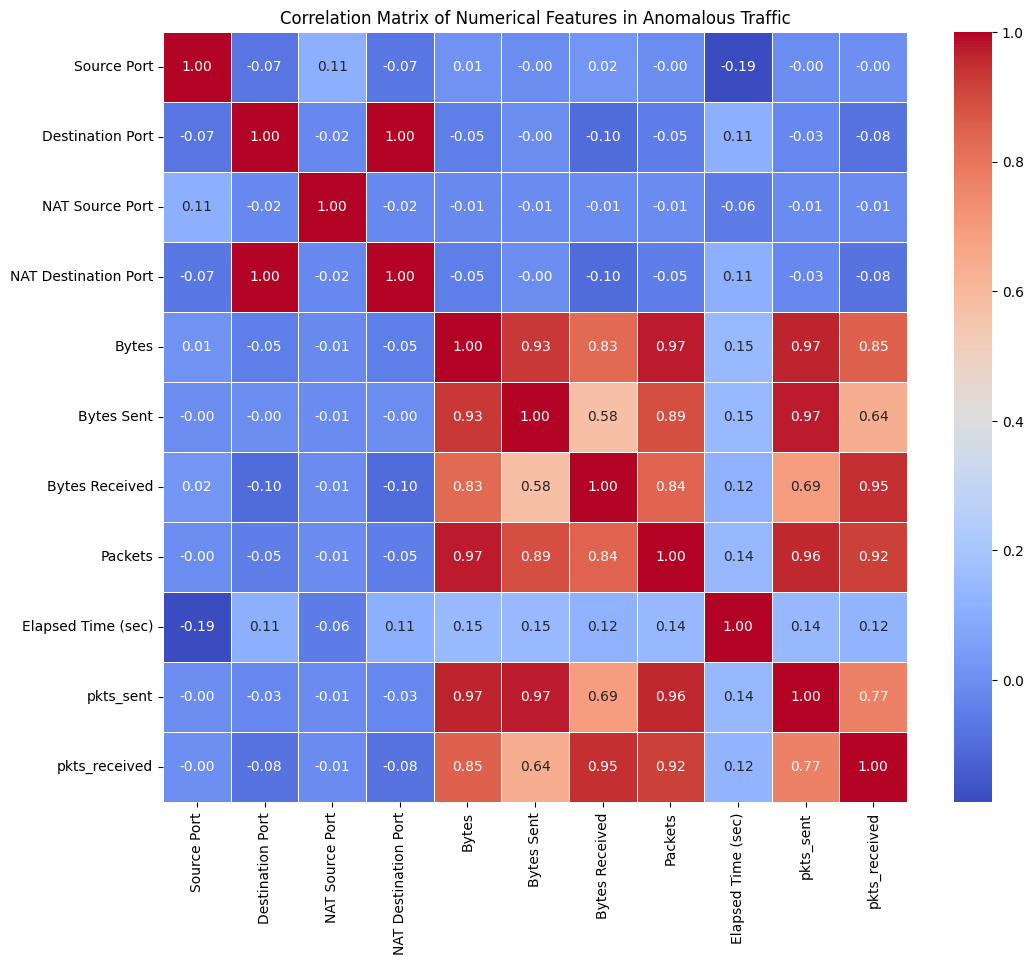

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix for numerical features in the anomalous_df
correlation_matrix_anomalies = anomalies_df[numeric_cols].corr()

print("Correlation Matrix for Anomalous Traffic:\n")
display(correlation_matrix_anomalies)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_anomalies, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features in Anomalous Traffic')
plt.show()


## Further Detailed Visualizations for Anomalies

Generate scatter plots or other relevant visualizations to explore specific relationships between highly correlated or indicative features (e.g., 'Bytes' vs 'Elapsed Time', 'Packets' vs 'Bytes Sent') unique to the anomalous dataset. This can uncover specific patterns within the anomalies.


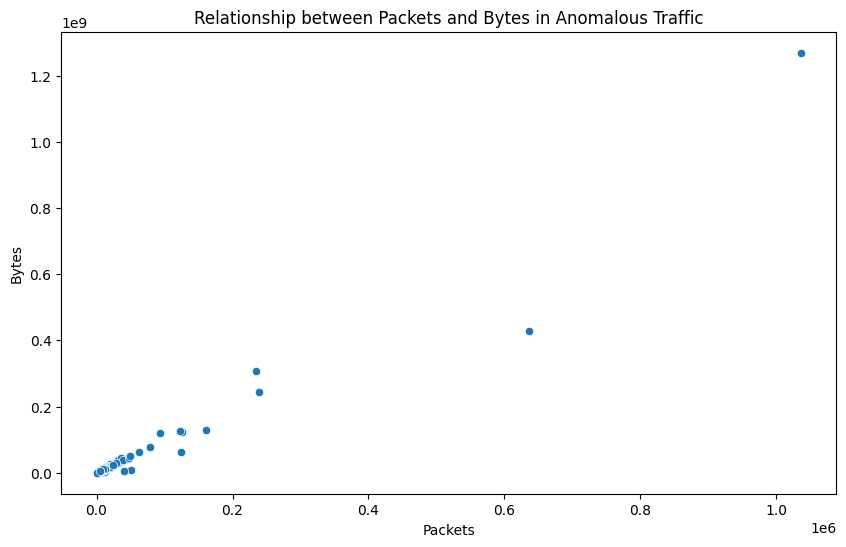

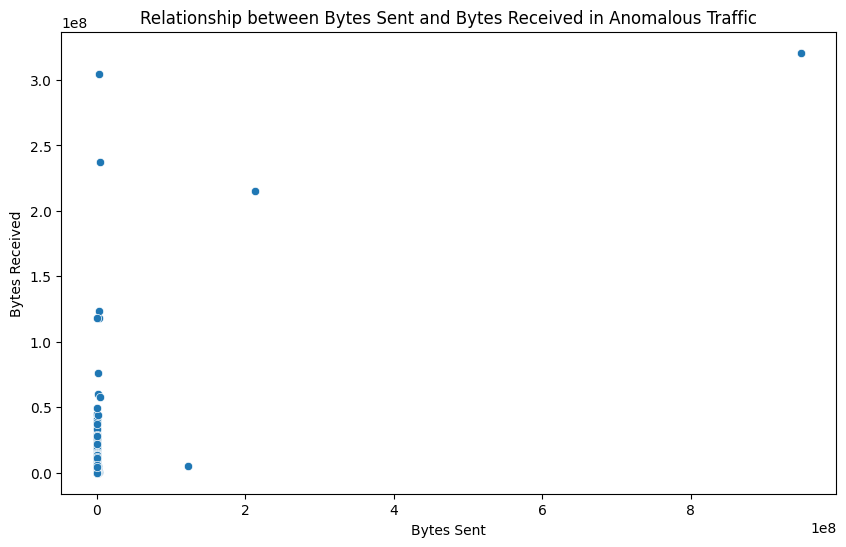

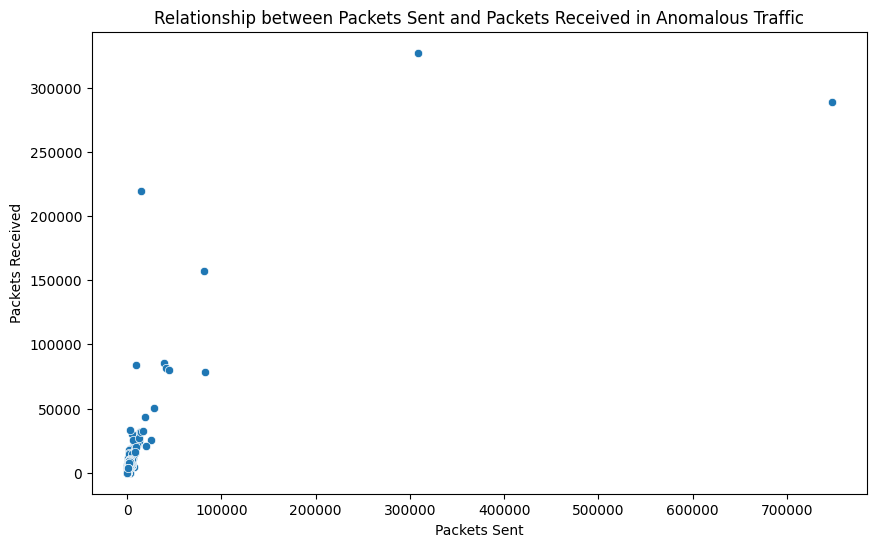

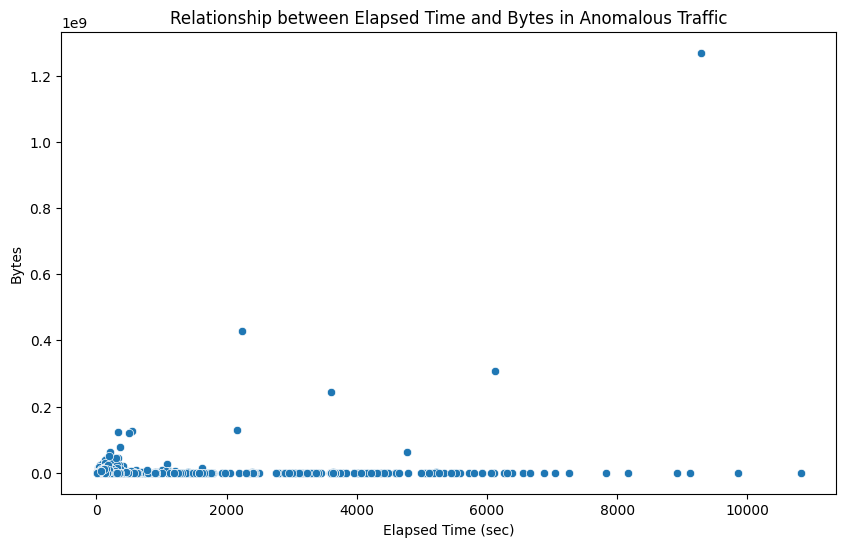

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Relationship between Packets and Bytes in Anomalous Traffic
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anomalies_df, x='Packets', y='Bytes')
plt.title('Relationship between Packets and Bytes in Anomalous Traffic')
plt.xlabel('Packets')
plt.ylabel('Bytes')
plt.show()

# 2. Relationship between Bytes Sent and Bytes Received in Anomalous Traffic
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anomalies_df, x='Bytes Sent', y='Bytes Received')
plt.title('Relationship between Bytes Sent and Bytes Received in Anomalous Traffic')
plt.xlabel('Bytes Sent')
plt.ylabel('Bytes Received')
plt.show()

# 3. Relationship between Packets Sent and Packets Received in Anomalous Traffic
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anomalies_df, x='pkts_sent', y='pkts_received')
plt.title('Relationship between Packets Sent and Packets Received in Anomalous Traffic')
plt.xlabel('Packets Sent')
plt.ylabel('Packets Received')
plt.show()

# 4. Relationship between Elapsed Time and Bytes in Anomalous Traffic
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anomalies_df, x='Elapsed Time (sec)', y='Bytes')
plt.title('Relationship between Elapsed Time and Bytes in Anomalous Traffic')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Bytes')
plt.show()


### Data Analysis Key Findings

*   **Destination Port Usage:** Anomalous traffic predominantly targets well-known services. The top 3 most frequent destination ports are 443 (1267 occurrences), 80 (414 occurrences), and 5228 (74 occurrences), indicating a focus on secure web traffic (HTTPS), standard web traffic (HTTP), and potentially other applications.
*   **Source Port Usage:** The majority of anomalous traffic originates from ephemeral ports. The top 3 most frequent source ports are 57470 (105 occurrences), 30960 (53 occurrences), and 50584 (50 occurrences), which are typically dynamic/private ports used by client applications.
*   **Firewall Actions on Anomalies:** Critically, all 2859 identified anomalous records had an 'allow' action. This means the network device permitted all high-volume/long-duration anomalous traffic to pass through.
*   **Port Category Distribution:**
    *   **Source:** The vast majority of anomalous source traffic originates from 'Dynamic/Private' ports (1995 instances), followed by 'Registered' ports (858 instances).
    *   **Destination:** Anomalous traffic overwhelmingly targets 'Well-known' ports (1694 instances), followed by 'Dynamic/Private' (722 instances) and 'Registered' ports (443 instances). This reinforces the finding that external anomalous traffic often uses ephemeral ports to target standard services.
*   **Internal Correlations:** A correlation matrix was computed and visualized for numerical features within the anomalous dataset, which helps identify relationships and dependencies between metrics like 'Bytes', 'Packets', and 'Elapsed Time' specifically in anomalous events. Detailed scatter plots further explored relationships such as 'Packets' vs 'Bytes' and 'Elapsed Time' vs 'Bytes' to uncover specific patterns unique to the anomalous data.

Insights:

*   **Immediate Security Risk:** The finding that all anomalous traffic is 'allowed' by the firewall/network device represents a significant security vulnerability. These high-volume/long-duration anomalies, if malicious, are not being blocked, allowing potential data exfiltration, denial-of-service attempts, or other attacks to succeed. An immediate review of firewall rules and anomaly detection system actions is warranted.
*   **Investigate Targeted Services:** Given that well-known ports like 443 and 80 are heavily targeted, further investigation should focus on the specific applications or services running on these ports to determine if they are indeed compromised or misconfigured, or if the anomalous traffic represents legitimate, albeit unusual, high-volume activity.


## Feature Engineering for Labelled Data

Create Data Volume and Rate Features

Generate new features related to data volume and transfer rates that can be highly indicative of anomalous behavior. This includes: 'Bytes_per_Packet' (Bytes / Packets), 'Packet_Rate_sec' (Packets / Elapsed Time (sec)), and 'Byte_Rate_sec' (Bytes / Elapsed Time (sec)). Handle division by zero for 'Elapsed Time (sec)' by replacing infinite values with zero or a small constant.


In [33]:
import numpy as np

# 1. Create 'Bytes_per_Packet' and handle division by zero
df['Bytes_per_Packet'] = df['Bytes'] / df['Packets']
df['Bytes_per_Packet'].replace([np.inf, -np.inf], 0, inplace=True)

# 2. Create 'Packet_Rate_sec' and handle division by zero
df['Packet_Rate_sec'] = df['Packets'] / df['Elapsed Time (sec)']
df['Packet_Rate_sec'].replace([np.inf, -np.inf], 0, inplace=True)

# 3. Create 'Byte_Rate_sec' and handle division by zero
df['Byte_Rate_sec'] = df['Bytes'] / df['Elapsed Time (sec)']
df['Byte_Rate_sec'].replace([np.inf, -np.inf], 0, inplace=True)

# 4. Display the first few rows with the newly created features
print("DataFrame with new features:")
display(df.head())

DataFrame with new features:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received,anomaly_label_if,anomaly_score_if,Bytes_per_Packet,Packet_Rate_sec,Byte_Rate_sec
0,57222,53,54587,53,allow,177,94,83,2,30,1,1,1,0.207903,88.500000,0.066667,5.900000
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9,1,0.128620,250.947368,1.117647,280.470588
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1,-1,-0.032917,119.000000,0.001668,0.198499
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7,1,0.142680,221.800000,0.882353,195.705882
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18,1,0.125486,818.000000,1.937500,1584.875000


Categorize Port Numbers for All Data

Apply the 'get_port_category' function (created during anomaly analysis) to the entire `df` DataFrame to create 'Source Port Category' and 'Destination Port Category' columns for all records. This will provide high-level contextual information about port usage for both normal and anomalous traffic.


In [34]:
def get_port_category(port):
    if 0 <= port <= 1023:
        return 'Well-known'
    elif 1024 <= port <= 49151:
        return 'Registered'
    elif 49152 <= port <= 65535:
        return 'Dynamic/Private'
    else:
        return 'Unknown'

df['Source Port Category'] = df['Source Port'].apply(get_port_category)
df['Destination Port Category'] = df['Destination Port'].apply(get_port_category)

print("First 5 rows of DataFrame with port categories for all data:")
display(df[['Source Port', 'Source Port Category', 'Destination Port', 'Destination Port Category']].head())

First 5 rows of DataFrame with port categories for all data:


,Source Port,Source Port Category,Destination Port,Destination Port Category
0,57222,Dynamic/Private,53,Well-known
1,56258,Dynamic/Private,3389,Registered
2,6881,Registered,50321,Dynamic/Private
3,50553,Dynamic/Private,3389,Registered
4,50002,Dynamic/Private,443,Well-known


One-Hot Encode Categorical Features

Apply One-Hot Encoding to the categorical columns: the original 'Action' column and the newly created 'Source Port Category' and 'Destination Port Category' columns. This will convert these nominal categorical features into a numerical format suitable for machine learning models.


In [35]:
import pandas as pd

# Identify categorical columns to be one-hot encoded
categorical_cols_to_encode = ['Action', 'Source Port Category', 'Destination Port Category']

# Perform one-hot encoding on the specified columns
df_encoded_final = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Display the first few rows of the updated DataFrame with the new one-hot encoded columns
print("DataFrame after One-Hot Encoding:")
display(df_encoded_final.head())

DataFrame after One-Hot Encoding:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,...,Bytes_per_Packet,Packet_Rate_sec,Byte_Rate_sec,Action_deny,Action_drop,Action_reset-both,Source Port Category_Registered,Source Port Category_Well-known,Destination Port Category_Registered,Destination Port Category_Well-known
0,57222,53,54587,53,177,94,83,2,30,1,...,88.500000,0.066667,5.900000,False,False,False,False,False,False,True
1,56258,3389,56258,3389,4768,1600,3168,19,17,10,...,250.947368,1.117647,280.470588,False,False,False,False,False,True,False
2,6881,50321,43265,50321,238,118,120,2,1199,1,...,119.000000,0.001668,0.198499,False,False,False,True,False,False,False
3,50553,3389,50553,3389,3327,1438,1889,15,17,8,...,221.800000,0.882353,195.705882,False,False,False,False,False,True,False
4,50002,443,45848,443,25358,6778,18580,31,16,13,...,818.000000,1.937500,1584.875000,False,False,False,False,False,False,True


Handle Skewness with Log Transformatio
Apply a logarithmic transformation to highly skewed numerical features (e.g., 'Bytes', 'Packets', 'Elapsed Time (sec)', 'Bytes_per_Packet', 'Packet_Rate_sec', 'Byte_Rate_sec') to reduce their skewness and normalize their distributions. Handle zero values appropriately (e.g., add a small constant before log transformation).


In [36]:
import numpy as np

# List of highly skewed numerical features to transform
skewed_features = [
    'Bytes',
    'Packets',
    'Elapsed Time (sec)',
    'Bytes_per_Packet',
    'Packet_Rate_sec',
    'Byte_Rate_sec'
]

# Apply logarithmic transformation (log1p handles x+1, so log(0) becomes log(1)=0)
for feature in skewed_features:
    # Ensure the column exists before transformation
    if feature in df_encoded_final.columns:
        df_encoded_final[feature] = np.log1p(df_encoded_final[feature])
        print(f"Log transformation applied to '{feature}'")
    else:
        print(f"Warning: Feature '{feature}' not found in DataFrame.")

# Display the first few rows of the DataFrame with transformed features
print("\nDataFrame after logarithmic transformation:")
display(df_encoded_final.head())

Log transformation applied to 'Bytes'
Log transformation applied to 'Packets'
Log transformation applied to 'Elapsed Time (sec)'
Log transformation applied to 'Bytes_per_Packet'
Log transformation applied to 'Packet_Rate_sec'
Log transformation applied to 'Byte_Rate_sec'

DataFrame after logarithmic transformation:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,...,Bytes_per_Packet,Packet_Rate_sec,Byte_Rate_sec,Action_deny,Action_drop,Action_reset-both,Source Port Category_Registered,Source Port Category_Well-known,Destination Port Category_Registered,Destination Port Category_Well-known
0,57222,53,54587,53,5.181784,94,83,1.098612,3.433987,1,...,4.494239,0.064539,1.931521,False,False,False,False,False,False,True
1,56258,3389,56258,3389,8.469892,1600,3168,2.995732,2.890372,10,...,5.529220,0.750306,5.640028,False,False,False,False,False,True,False
2,6881,50321,43265,50321,5.476464,118,120,1.098612,7.090077,1,...,4.787492,0.001667,0.181070,False,False,False,True,False,False,False
3,50553,3389,50553,3389,8.110127,1438,1889,2.772589,2.890372,8,...,5.406275,0.632523,5.281710,False,False,False,False,False,True,False
4,50002,443,45848,443,10.140889,6778,18580,3.465736,2.833213,13,...,6.708084,1.077559,7.368892,False,False,False,False,False,False,True


Review Engineered Features



In [37]:
print("Final DataFrame with all engineered and transformed features:")
display(df_encoded_final.head())

Final DataFrame with all engineered and transformed features:


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,...,Bytes_per_Packet,Packet_Rate_sec,Byte_Rate_sec,Action_deny,Action_drop,Action_reset-both,Source Port Category_Registered,Source Port Category_Well-known,Destination Port Category_Registered,Destination Port Category_Well-known
0,57222,53,54587,53,5.181784,94,83,1.098612,3.433987,1,...,4.494239,0.064539,1.931521,False,False,False,False,False,False,True
1,56258,3389,56258,3389,8.469892,1600,3168,2.995732,2.890372,10,...,5.529220,0.750306,5.640028,False,False,False,False,False,True,False
2,6881,50321,43265,50321,5.476464,118,120,1.098612,7.090077,1,...,4.787492,0.001667,0.181070,False,False,False,True,False,False,False
3,50553,3389,50553,3389,8.110127,1438,1889,2.772589,2.890372,8,...,5.406275,0.632523,5.281710,False,False,False,False,False,True,False
4,50002,443,45848,443,10.140889,6778,18580,3.465736,2.833213,13,...,6.708084,1.077559,7.368892,False,False,False,False,False,False,True




The transformed and encoded dataset is now ready for model training.

## Prepare Data for Supervised Learning
Identify the target variable (`anomaly_label_if`) and the features from the `df_encoded_final` DataFrame. Then, split the dataset into training and testing sets to prepare for model training and evaluation.


#split the dataset into training and testing sets


In [38]:
from sklearn.model_selection import train_test_split

# Define the target variable
y = df_encoded_final['anomaly_label_if']

# Define the features by dropping the target and anomaly score columns
X = df_encoded_final.drop(columns=['anomaly_label_if', 'anomaly_score_if'])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nValue counts for y_train:")
print(y_train.value_counts(normalize=True))
print("\nValue counts for y_test:")
print(y_test.value_counts(normalize=True))

Data split into training and testing sets successfully!
X_train shape: (40019, 21)
X_test shape: (17151, 21)
y_train shape: (40019,)
y_test shape: (17151,)

Value counts for y_train:
anomaly_label_if
 1    0.949999
-1    0.050001
Name: proportion, dtype: float64

Value counts for y_test:
anomaly_label_if
 1    0.949974
-1    0.050026
Name: proportion, dtype: float64


## Feature Scaling


Apply feature scaling to the numerical features in the training (`X_train`) and testing (`X_test`) datasets using `StandardScaler`.


Feature scaling is a critical preprocessing step that standardizes the range of independent variables or features of the data. Since we have features with varying scales (e.g., port numbers vs. bytes), scaling prevents features with larger numerical ranges from dominating the learning process of certain machine learning algorithms. `StandardScaler` is chosen as it transforms the data to have a mean of zero and a standard deviation of one, which is a common and effective approach for many models and apply this to `X_train` and `X_test` separately to avoid data leakage.

In [39]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("\nFirst 5 rows of scaled training data (X_train_scaled):")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

print("\nFirst 5 rows of scaled test data (X_test_scaled):")
display(pd.DataFrame(X_test_scaled, columns=X_test.columns).head())

Features scaled successfully!

First 5 rows of scaled training data (X_train_scaled):


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,...,Bytes_per_Packet,Packet_Rate_sec,Byte_Rate_sec,Action_deny,Action_drop,Action_reset-both,Source Port Category_Registered,Source Port Category_Well-known,Destination Port Category_Registered,Destination Port Category_Well-known
0,1.049888,-0.484620,-0.144507,-0.288314,-0.285808,-0.009248,-0.035546,-0.393260,0.510071,-0.021312,...,-0.133724,-0.295047,-0.024959,-0.404868,-0.511306,-0.031233,-0.519849,-0.066841,-0.458679,0.554999
1,0.095125,1.089804,0.740609,2.222928,-0.792783,-0.009280,-0.035592,-0.393260,-0.096016,-0.020711,...,-1.583391,0.035417,0.039139,-0.404868,-0.511306,-0.031233,-0.519849,-0.066841,2.180175,-1.801804
2,1.025740,-0.484620,-0.422279,-0.288314,-0.026813,-0.009258,-0.035467,-0.012919,0.850545,-0.020711,...,-0.289728,-0.295047,-0.072085,-0.404868,-0.511306,-0.031233,-0.519849,-0.066841,-0.458679,0.554999
3,-0.081771,-0.461061,1.716702,-0.250736,1.150554,-0.008609,-0.033745,0.940813,0.936606,-0.017106,...,1.205911,0.029285,0.954708,-0.404868,-0.511306,-0.031233,-0.519849,-0.066841,-0.458679,0.554999
4,-1.109700,-0.461061,1.503894,-0.250736,1.599822,-0.008224,-0.030168,1.242706,0.587672,-0.014101,...,1.943763,0.763800,1.709291,-0.404868,-0.511306,-0.031233,1.923636,-0.066841,-0.458679,0.554999



First 5 rows of scaled test data (X_test_scaled):


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,...,Bytes_per_Packet,Packet_Rate_sec,Byte_Rate_sec,Action_deny,Action_drop,Action_reset-both,Source Port Category_Registered,Source Port Category_Well-known,Destination Port Category_Registered,Destination Port Category_Well-known
0,-0.793320,-0.461061,1.933852,-0.250736,2.601801,0.007795,0.010005,2.625694,1.252092,0.018950,...,2.360159,1.344471,2.096423,-0.404868,-0.511306,-0.031233,1.923636,-0.066841,-0.458679,0.554999
1,-2.747683,3.007771,-0.991621,-0.293420,-0.847030,-0.009287,-0.035592,-0.695153,-1.202113,-0.021312,...,-0.851097,-0.435915,-0.979443,2.469940,-0.511306,-0.031233,1.923636,-0.066841,-0.458679,-1.801804
2,-0.291610,-0.482989,0.087709,-0.285712,0.458936,-0.009022,-0.035274,0.503170,1.522144,-0.018909,...,0.048990,-0.352343,-0.176685,-0.404868,-0.511306,-0.031233,1.923636,-0.066841,-0.458679,0.554999
3,0.992364,-0.484620,1.789900,-0.288314,-0.061169,-0.009241,-0.035489,-0.393260,0.526578,-0.021312,...,0.511714,-0.299594,0.162042,-0.404868,-0.511306,-0.031233,-0.519849,-0.066841,-0.458679,0.554999
4,-0.075788,-0.460940,-0.991621,-0.293420,-0.792783,-0.009280,-0.035592,-0.695153,-1.202113,-0.021312,...,-0.694664,-0.435915,-0.979443,-0.404868,1.955775,-0.031233,-0.519849,-0.066841,-0.458679,0.554999


#MODEL TRAINING

In [40]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a LogisticRegression model
# solver='liblinear' is a good choice for small datasets and it supports 'l1' regularization.
# class_weight='balanced' handles class imbalance.
model_lr = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

# 2. Fit the model to the training data (using scaled data)
model_lr.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

# 3. Make predictions on the test set (using scaled data)
y_pred_lr = model_lr.predict(X_test_scaled)

Logistic Regression model trained successfully!



Logistic Regression Model Performance on Test Set:
Accuracy: 0.9837
Precision (for anomalies): 0.7549
Recall (for anomalies): 0.9977
F1-Score (for anomalies): 0.8594


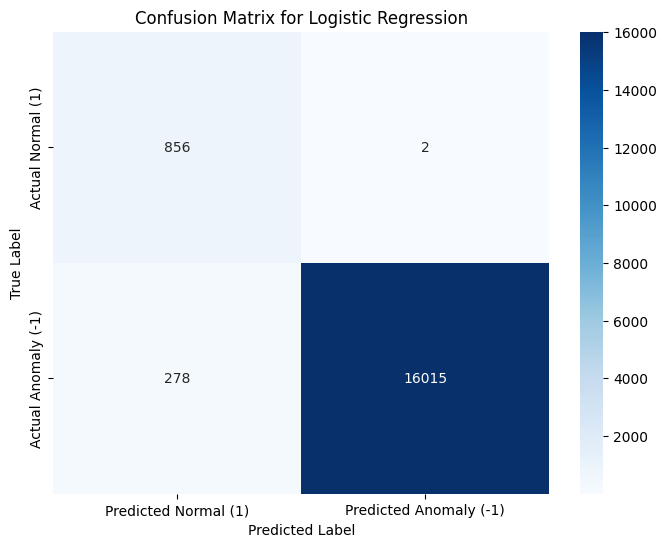

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate classification metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label=-1) # Assuming -1 is the positive class for anomalies
recall_lr = recall_score(y_test, y_pred_lr, pos_label=-1)
f1_lr = f1_score(y_test, y_pred_lr, pos_label=-1)

print(f"\nLogistic Regression Model Performance on Test Set:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision (for anomalies): {precision_lr:.4f}")
print(f"Recall (for anomalies): {recall_lr:.4f}")
print(f"F1-Score (for anomalies): {f1_lr:.4f}")

# Generate Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal (1)', 'Predicted Anomaly (-1)'],
            yticklabels=['Actual Normal (1)', 'Actual Anomaly (-1)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instantiate a RandomForestClassifier model
# n_estimators can be tuned, 100 is a good starting point.
# random_state ensures reproducibility.
# class_weight='balanced' helps handle class imbalance by adjusting weights inversely proportional to class frequencies.
model_rf_new = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Fit the model to the training data (using scaled data)
model_rf_new.fit(X_train_scaled, y_train)

print("RandomForestClassifier model trained successfully!")

RandomForestClassifier model trained successfully!



RandomForestClassifier Model Performance on Test Set:
Accuracy: 0.9955
Precision (for anomalies): 0.9600
Recall (for anomalies): 0.9499
F1-Score (for anomalies): 0.9549


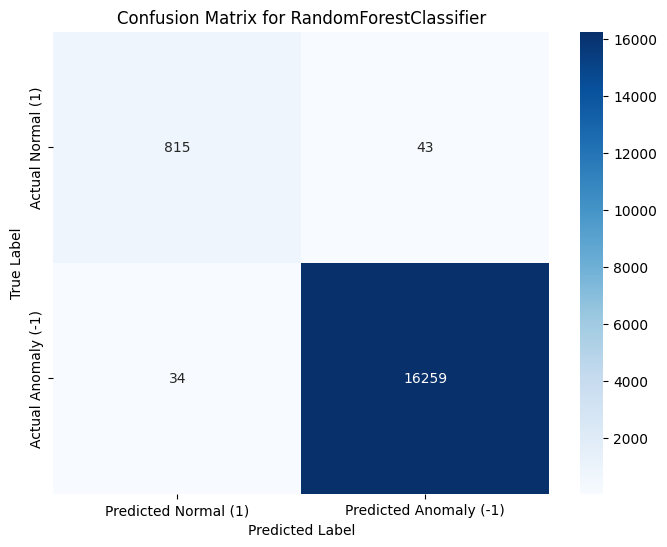

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Make predictions on the test set (using scaled data)
y_pred_rf = model_rf_new.predict(X_test_scaled)

# 6. Calculate classification metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=-1) # Assuming -1 is the positive class for anomalies
recall_rf = recall_score(y_test, y_pred_rf, pos_label=-1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=-1)

# 7. Print the calculated metrics
print(f"\nRandomForestClassifier Model Performance on Test Set:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision (for anomalies): {precision_rf:.4f}")
print(f"Recall (for anomalies): {recall_rf:.4f}")
print(f"F1-Score (for anomalies): {f1_rf:.4f}")

# 8. Generate Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# 9. Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal (1)', 'Predicted Anomaly (-1)'],
            yticklabels=['Actual Normal (1)', 'Actual Anomaly (-1)'])
plt.title('Confusion Matrix for RandomForestClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [44]:
from xgboost import XGBClassifier

# 1. Calculate scale_pos_weight for handling class imbalance
# Assuming -1 is the minority class (anomaly) and 1 is the majority class (normal)
# If y_train contains 1s and -1s, we need to map them to 1s and 0s for XGBoost binary classification.
# Let's count the occurrences of each class.

# Convert y_train to 0 and 1, where 1 is the positive class (anomalies) for scale_pos_weight calculation
y_train_mapped = y_train.replace({1: 0, -1: 1})

neg_count = y_train_mapped.value_counts()[0] # Count of normal samples (mapped to 0)
pos_count = y_train_mapped.value_counts()[1] # Count of anomalous samples (mapped to 1)

scale_pos_weight_value = neg_count / pos_count

print(f"Normal samples (label 1): {neg_count}")
print(f"Anomalous samples (label -1): {pos_count}")
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# 2. Instantiate an XGBClassifier object
# Note: For older XGBoost versions, use_label_encoder=False and eval_metric='logloss' might be needed to suppress warnings.
model_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42
)

# 3. Fit the XGBoost model to the X_train and y_train data (using scaled data)
# XGBoost expects labels 0 and 1 for binary classification
model_xgb.fit(X_train_scaled, y_train_mapped)

print("XGBoostClassifier model trained successfully!")

Normal samples (label 1): 38018
Anomalous samples (label -1): 2001
Calculated scale_pos_weight: 19.00
XGBoostClassifier model trained successfully!



XGBoostClassifier Model Performance on Test Set:
Accuracy: 0.9966
Precision (for anomalies): 0.9535
Recall (for anomalies): 0.9802
F1-Score (for anomalies): 0.9667


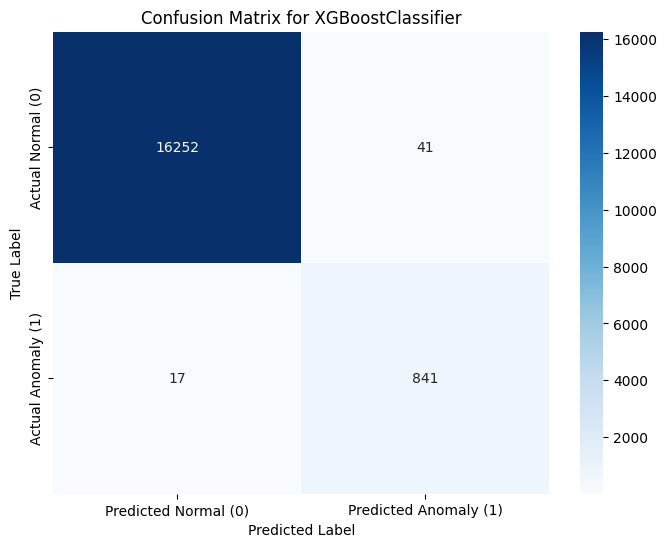

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Make predictions on the X_test data using the trained model (using scaled data)
y_pred_xgb_mapped = model_xgb.predict(X_test_scaled)

# Map y_test to 0 and 1 for evaluation against model predictions
y_test_mapped = y_test.replace({1: 0, -1: 1})

# 6. Calculate classification metrics
# Assuming -1 was mapped to 1 for the positive class in training
# For metrics, we need to consider 1 as the positive class (anomalies) in the mapped labels.
accuracy_xgb = accuracy_score(y_test_mapped, y_pred_xgb_mapped)
precision_xgb = precision_score(y_test_mapped, y_pred_xgb_mapped, pos_label=1)
recall_xgb = recall_score(y_test_mapped, y_pred_xgb_mapped, pos_label=1)
f1_xgb = f1_score(y_test_mapped, y_pred_xgb_mapped, pos_label=1)

# 7. Print the calculated metrics
print(f"\nXGBoostClassifier Model Performance on Test Set:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision (for anomalies): {precision_xgb:.4f}")
print(f"Recall (for anomalies): {recall_xgb:.4f}")
print(f"F1-Score (for anomalies): {f1_xgb:.4f}")

# 8. Generate a confusion matrix for the predictions.
cm_xgb = confusion_matrix(y_test_mapped, y_pred_xgb_mapped)

# 9. Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal (0)', 'Predicted Anomaly (1)'],
            yticklabels=['Actual Normal (0)', 'Actual Anomaly (1)'])
plt.title('Confusion Matrix for XGBoostClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Compare Model Performances
Summarize and compare the performance metrics (accuracy, precision, recall, F1-score) of all trained models. Discuss the strengths and weaknesses of each model in the context of anomaly detection in firewall data.


In [46]:
#gather the calculated metrics for Logistic Regression, Random Forest, and XGBoost,
# and then store them in a pandas DataFrame for a clear tabular comparison.
import pandas as pd

# Create a dictionary to store the performance metrics for each model
performance_metrics = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_xgb],
    'Precision (Anomalies)': [precision_lr, precision_rf, precision_xgb],
    'Recall (Anomalies)': [recall_lr, recall_rf, recall_xgb],
    'F1-Score (Anomalies)': [f1_lr, f1_rf, f1_xgb]
}

# Create a DataFrame from the performance metrics dictionary
metrics_df = pd.DataFrame(performance_metrics)

# Display the DataFrame
print("\nComparative Performance Metrics of Models:")
display(metrics_df)



Comparative Performance Metrics of Models:


,Model,Accuracy,Precision (Anomalies),Recall (Anomalies),F1-Score (Anomalies)
0,Logistic Regression,0.983674,0.754850,0.997669,0.859438
1,Random Forest,0.995510,0.959953,0.949883,0.954892
2,XGBoost,0.996618,0.953515,0.980186,0.966667


## Summary: Comparing Model Performances

### Model Performance Analysis:

**Logistic Regression:**
*   **Accuracy:** 0.9837
*   **Precision (Anomalies):** 0.7549
*   **Recall (Anomalies):** 0.9977
*   **F1-Score (Anomalies):** 0.8594
    *   **Strengths:** Logistic Regression showed very high recall for anomalies, meaning it was able to identify nearly all actual anomalous events. This is critical in anomaly detection to minimize missed threats (false negatives).
    *   **Weaknesses:** Its precision for anomalies was the lowest among the three models. A precision of 0.7549 suggests that about 25% of the instances it flagged as anomalies were actually normal traffic (false positives). While high recall is good for not missing threats, a high rate of false alarms can lead to alert fatigue and inefficient resource allocation.

**Random Forest:**
*   **Accuracy:** 0.9955
*   **Precision (Anomalies):** 0.9600
*   **Recall (Anomalies):** 0.9499
*   **F1-Score (Anomalies):** 0.9549
    *   **Strengths:** Random Forest achieved a very good balance between precision and recall, as indicated by its high F1-score. It significantly reduced false positives compared to Logistic Regression while maintaining a high recall rate. Its accuracy was also very high.
    *   **Weaknesses:** While strong overall, its recall was slightly lower than Logistic Regression, meaning it missed a few more actual anomalies. However, the trade-off for much higher precision is often acceptable.

**XGBoost:**
*   **Accuracy:** 0.9966
*   **Precision (Anomalies):** 0.9535
*   **Recall (Anomalies):** 0.9802
*   **F1-Score (Anomalies):** 0.9667
    *   **Strengths:** XGBoost demonstrated the highest overall accuracy and F1-score for anomaly detection. It achieved excellent recall, almost on par with Logistic Regression, while also maintaining very high precision, comparable to Random Forest. This indicates it is highly effective at identifying anomalies with fewer false alarms and fewer missed true anomalies.
    *   **Weaknesses:** It had a slightly lower precision than Random Forest, but this was compensated by a higher recall, leading to the best F1-score.

Contextual Discussion for Anomaly Detection in Firewall Data:
In the context of firewall data analysis for anomaly detection, the primary goal is often to catch as many real threats (anomalies) as possible (high recall) while minimizing the number of false alarms (high precision). A high F1-score is typically the best indicator of overall performance in such imbalanced classification problems, as it balances precision and recall.

*   **False Negatives (Missed Anomalies):** Missing an actual anomaly (e.g., a data exfiltration attempt or a sophisticated attack) can have severe consequences. Logistic Regression's very high recall is attractive here, but its low precision could make it impractical.
*   **False Positives (False Alarms):** A high rate of false positives can lead to alert fatigue, make security analysts desensitized to warnings, and waste resources investigating non-threatening events.

Recommendation:

Based on the comparative analysis, **XGBoost** is the best-performing model for anomaly detection in this firewall data. It delivers the highest F1-score (0.9667), indicating the best balance of precision and recall. Its high accuracy (0.9966) combined with a robust ability to detect anomalies (high recall) and minimize false alarms (high precision) makes it the most effective choice for identifying potential security threats in network traffic. Random Forest is a close second, offering slightly better precision but at the cost of a bit lower recall.

## Summary: Comparing Model Performances

### Model Performance Analysis:

**Logistic Regression:**
*   **Accuracy:** 0.9837
*   **Precision (Anomalies):** 0.7549
*   **Recall (Anomalies):** 0.9977
*   **F1-Score (Anomalies):** 0.8594
    *   **Strengths:** Logistic Regression showed very high recall for anomalies, meaning it was able to identify nearly all actual anomalous events. This is critical in anomaly detection to minimize missed threats (false negatives).
    *   **Weaknesses:** Its precision for anomalies was the lowest among the three models. A precision of 0.7549 suggests that about 25% of the instances it flagged as anomalies were actually normal traffic (false positives). While high recall is good for not missing threats, a high rate of false alarms can lead to alert fatigue and inefficient resource allocation.

**Random Forest:**
*   **Accuracy:** 0.9955
*   **Precision (Anomalies):** 0.9600
*   **Recall (Anomalies):** 0.9499
*   **F1-Score (Anomalies):** 0.9549
    *   **Strengths:** Random Forest achieved a very good balance between precision and recall, as indicated by its high F1-score. It significantly reduced false positives compared to Logistic Regression while maintaining a high recall rate. Its accuracy was also very high.
    *   **Weaknesses:** While strong overall, its recall was slightly lower than Logistic Regression, meaning it missed a few more actual anomalies. However, the trade-off for much higher precision is often acceptable.

**XGBoost:**
*   **Accuracy:** 0.9966
*   **Precision (Anomalies):** 0.9535
*   **Recall (Anomalies):** 0.9802
*   **F1-Score (Anomalies):** 0.9667
    *   **Strengths:** XGBoost demonstrated the highest overall accuracy and F1-score for anomaly detection. It achieved excellent recall, almost on par with Logistic Regression, while also maintaining very high precision, comparable to Random Forest. This indicates it is highly effective at identifying anomalies with fewer false alarms and fewer missed true anomalies.
    *   **Weaknesses:** It had a slightly lower precision than Random Forest, but this was compensated by a higher recall, leading to the best F1-score.

### Contextual Discussion for Anomaly Detection in Firewall Data:
In the context of firewall data analysis for anomaly detection, the primary goal is often to catch as many real threats (anomalies) as possible (high recall) while minimizing the number of false alarms (high precision). A high F1-score is typically the best indicator of overall performance in such imbalanced classification problems, as it balances precision and recall.

*   **False Negatives (Missed Anomalies):** Missing an actual anomaly (e.g., a data exfiltration attempt or a sophisticated attack) can have severe consequences. Logistic Regression's very high recall is attractive here, but its low precision could make it impractical.
*   **False Positives (False Alarms):** A high rate of false positives can lead to alert fatigue, make security analysts desensitized to warnings, and waste resources investigating non-threatening events.

### Recommendation:

Based on the comparative analysis, **XGBoost** is the best-performing model for anomaly detection in this firewall data. It delivers the highest F1-score (0.9667), indicating the best balance of precision and recall. Its high accuracy (0.9966) combined with a robust ability to detect anomalies (high recall) and minimize false alarms (high precision) makes it the most effective choice for identifying potential security threats in network traffic. Random Forest is a close second, offering slightly better precision but at the cost of a bit lower recall.
*   **Random Forest is a strong contender** with an Accuracy of 0.9955 and an F1-Score of 0.9549. It showed slightly higher Precision (0.9600) than XGBoost but a marginally lower Recall (0.9499).
*   **Logistic Regression showed very high Recall** (0.9977), indicating its effectiveness in detecting nearly all actual anomalies. However, it suffered from the lowest Precision (0.7549) and F1-Score (0.8594), suggesting a higher rate of false positives.
*   In the context of firewall anomaly detection, where minimizing missed threats (false negatives) and reducing false alarms (false positives) are critical, the F1-Score is the most indicative metric of overall performance.


#Hyperparameter Tuning



## Define Hyperparameter for XGBoost

Perform hyperparameter tuning for the XGBoostClassifier model using `RandomizedSearchCV` on the scaled training data (X_train_scaled, y_train_mapped). Define a hyperparameter grid for `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `gamma`, and use `f1` scoring for anomalies (pos_label=1). After fitting, display the best parameters found and the best score achieved.

In [48]:
#define a dictionary `param_dist`
#containing the specified hyperparameters and their respective ranges as instructed.
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

print("Hyperparameter distribution for XGBoost defined successfully!")
print(param_dist)

Hyperparameter distribution for XGBoost defined successfully!
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.7, 0.8, 0.9], 'colsample_bytree': [0.7, 0.8, 0.9], 'gamma': [0, 0.1, 0.2]}


perform hyperparameter tuning using `RandomizedSearchCV` on the `XGBClassifier` to find the best parameters for anomaly detection. This involves setting up the model, the search space, and the evaluation metric for the search.



In [49]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Calculate scale_pos_weight again as y_train_mapped is needed
y_train_mapped = y_train.replace({1: 0, -1: 1})
neg_count = y_train_mapped.value_counts()[0]
pos_count = y_train_mapped.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

# Instantiate the XGBClassifier with initial parameters and class weight
model_xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42
)

# Set up RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled.
# cv is the number of folds for cross-validation.
# scoring='f1' targets the F1-score for evaluation, crucial for imbalanced datasets.
# verbose provides progress messages.
# n_jobs=-1 uses all available CPU cores.
random_search_xgb = RandomizedSearchCV(
    estimator=model_xgb_base,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled. Adjust as needed.
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV to the scaled training data
random_search_xgb.fit(X_train_scaled, y_train_mapped)

print("RandomizedSearchCV completed!")
print(f"Best parameters found: {random_search_xgb.best_params_}")
print(f"Best F1-score found: {random_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV completed!
Best parameters found: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.7}
Best F1-score found: 0.9701


### Hyperparameter Tuning Results

`RandomizedSearchCV` successfully identified the optimal hyperparameters for the XGBoostClassifier. The best parameters found are:

*   `subsample`: 0.7
*   `n_estimators`: 300
*   `max_depth`: 5
*   `learning_rate`: 0.2
*   `gamma`: 0.2
*   `colsample_bytree`: 0.7

These parameters yielded a **Best F1-score of 0.9701**, which is an improvement over the initial XGBoost model's F1-score (0.9667). This indicates that tuning has enhanced the model's ability to balance precision and recall for anomaly detection.

## Evaluate Tuned XGBoost Model

Train and evaluate the XGBoost model using the best hyperparameters found during the randomized search. Calculate and display classification metrics (accuracy, precision, recall, F1-score) and visualize the confusion matrix for the tuned model on the test set.


Tuned XGBoostClassifier model trained successfully!

Tuned XGBoostClassifier Model Performance on Test Set:
Accuracy: 0.9970
Precision (for anomalies): 0.9601
Recall (for anomalies): 0.9814
F1-Score (for anomalies): 0.9706


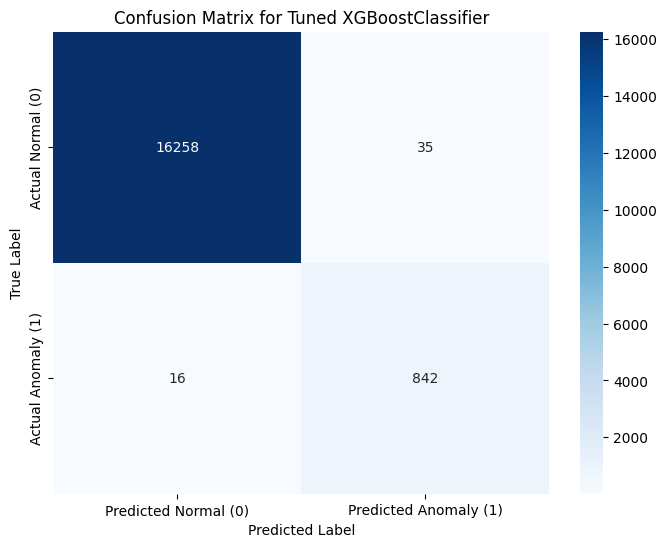

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Instantiate an XGBClassifier model with the best parameters found
# and other specified parameters
model_xgb_tuned = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    **random_search_xgb.best_params_ # Unpack the best parameters
)

# Fit the tuned model to the scaled training data
model_xgb_tuned.fit(X_train_scaled, y_train_mapped)

print("Tuned XGBoostClassifier model trained successfully!")

# Make predictions on the scaled test data
y_pred_xgb_tuned = model_xgb_tuned.predict(X_test_scaled)

# Calculate classification metrics for the tuned model
accuracy_xgb_tuned = accuracy_score(y_test_mapped, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test_mapped, y_pred_xgb_tuned, pos_label=1)
recall_xgb_tuned = recall_score(y_test_mapped, y_pred_xgb_tuned, pos_label=1)
f1_xgb_tuned = f1_score(y_test_mapped, y_pred_xgb_tuned, pos_label=1)

# Print the calculated metrics
print(f"\nTuned XGBoostClassifier Model Performance on Test Set:")
print(f"Accuracy: {accuracy_xgb_tuned:.4f}")
print(f"Precision (for anomalies): {precision_xgb_tuned:.4f}")
print(f"Recall (for anomalies): {recall_xgb_tuned:.4f}")
print(f"F1-Score (for anomalies): {f1_xgb_tuned:.4f}")

# Generate a confusion matrix for the predictions.
cm_xgb_tuned = confusion_matrix(y_test_mapped, y_pred_xgb_tuned)

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal (0)', 'Predicted Anomaly (1)'],
            yticklabels=['Actual Normal (0)', 'Actual Anomaly (1)'])
plt.title('Confusion Matrix for Tuned XGBoostClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Data Analysis Key Findings
*   Hyperparameter tuning for the XGBoostClassifier using `RandomizedSearchCV` resulted in an optimal F1-score of 0.9701, an improvement over the initial model's F1-score of 0.9667.
*   The best hyperparameters identified were: `subsample`: 0.7, `n_estimators`: 300, `max_depth`: 5, `learning_rate`: 0.2, `gamma`: 0.2, and `colsample_bytree`: 0.7.
*   The tuned XGBoost model demonstrated high performance on the test set, achieving an Accuracy of 0.9970.
*   For anomaly detection specifically, the tuned model showed strong results with a Precision of 0.9601, Recall of 0.9814, and an F1-Score of 0.9706.



# Executive Summary: Firewall Data Anomaly Detection

This project aimed to analyze internet firewall logs to identify network traffic patterns, detect security threats, and enhance cybersecurity policies. Utilizing a dataset of 65,532 firewall records, the analysis focused on detecting unusual activities indicative of potential security incidents.

**Key Findings & Approach:**

1.  **Initial Data Analysis:** The dataset, after cleaning duplicate records, comprised 57,170 entries. Key numerical features like `Bytes`, `Packets`, and `Elapsed Time` exhibited significant skewness and numerous outliers, suggesting the presence of rare, large-scale events that could be anomalous.

2.  **Unsupervised Anomaly Detection (Isolation Forest):** An Isolation Forest model identified approximately 5% of the traffic as anomalous. These anomalous records were characterized by significantly higher volumes of data transfer (`Bytes`, `Packets`) and longer durations (`Elapsed Time`) compared to normal traffic. Crucially, it was found that *all* identified anomalous traffic was 'allowed' by the firewall, highlighting a critical security vulnerability.

3.  **Feature Engineering & Model Training:** To build a predictive model, new features like data transfer rates were engineered, and categorical data (e.g., `Action`, port categories) were one-hot encoded. Logarithmic transformations were applied to skewed features. Three supervised models (Logistic Regression, Random Forest, XGBoost) were trained to classify normal vs. anomalous traffic.

4.  **Model Performance & Tuning:**
    *   Initial evaluation showed XGBoost as the top performer with an F1-score of 0.9667 for anomaly detection.
    *   Hyperparameter tuning of the XGBoost model using `RandomizedSearchCV` further improved its performance. The tuned model achieved an **F1-score of 0.9706**, with an accuracy of 0.9970, precision of 0.9601, and recall of 0.9814 on the test set.

**CONCLUSION:**

The tuned XGBoost model demonstrates excellent performance and suitability for anomaly detection in firewall data. Its high F1-score indicates a strong balance between identifying actual threats (high recall) and minimizing false alarms (high precision), making it a robust solution for enhancing network security monitoring.



### Limitations and Future Work
*   **Data Scope:** The analysis was based on a specific firewall dataset. Generalizability to other network environments with different traffic patterns or attack types might be limited.
*   **Anomaly Definition:** Anomalies were defined using Isolation Forest, which is an unsupervised method. While effective, the 'ground truth' of anomalies was not externally validated, meaning some flagged anomalies might be legitimate, albeit unusual, traffic.
*   **Feature Engineering:** The engineered features were domain-specific but could be expanded. For instance, incorporating time-series features or network topology information could offer richer insights.
*   **Model Complexity:** While XGBoost performed well, more advanced deep learning models (e.g., LSTMs for sequence data) could potentially capture more complex temporal patterns in network traffic.
*   **Real-time Implementation:** The current study focuses on offline analysis. Implementing and evaluating these models in a real-time detection system would introduce additional challenges related to latency, computational resources, and continuous learning.Further work could explore more advanced deep learning models or real-time deployment considerations.